<a href="https://colab.research.google.com/github/lirazshimon11/Data-Science-Course---Assignments/blob/main/%D7%A2%D7%91%D7%95%D7%93%D7%AA_%D7%91%D7%99%D7%AA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

שם סטודנט: לירז שמעון
ת.ז: 326720505

In [78]:
!kaggle datasets download arjunbhasin2013/ccdata
!unzip ccdata.zip

Dataset URL: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata
License(s): CC0-1.0
100% 340k/340k [00:00<00:00, 90.9MB/s]

Archive:  ccdata.zip
  inflating: CC GENERAL.csv          


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import plotly.express as px
import time


In [80]:
df = pd.read_csv("CC GENERAL.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [81]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [82]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


## 1. Dataset Selection

To fulfill the requirements of this assignment, I selected the **"Credit Card Dataset for Clustering"**. I chose this dataset because it fits unsupervised learning: it contains customer behavior data without pre-labeled clusters or anomaly labels. It contains 8,950 records and 17 numerical behavioral features and one customer ID column detailing customer behavior, with absolutely no pre-labeled target variables or anomaly flags.

Here is the detailed breakdown of the dataset according to the assignment requirements:

* **Where the dataset comes from:** Kaggle.

* **Why it was collected:** According to the dataset's documentation, the primary business case is to develop customer segmentation to define a targeted marketing strategy. It summarizes the usage and purchasing behavior of active credit card holders over a 6-month period.

* **Who collected it (if known):** Unknown. The specific financial institution remains anonymized for privacy reasons.

* **What each feature represents:** The 18 features capture various dimensions of consumer behavior over a 6-month period. The primary categories include:
  * `BALANCE`: The outstanding debt owed by the customer.
  * `CREDIT_LIMIT`: The maximum allowable debt limit for the user.
  * `PURCHASES`: The total monetary volume of all purchases.
  * `ONEOFF_PURCHASES` & `INSTALLMENTS_PURCHASES`: The breakdown of purchases into single-payment transactions versus installment plans.
  * `CASH_ADVANCE`: The amount of cash liquidity withdrawn by the user against their credit line.
  * `PAYMENTS` & `MINIMUM_PAYMENTS`: The user's repayment habits and mandatory minimums.
  * **Frequency and Count Variables** (e.g., `PURCHASES_FREQUENCY`, `PURCHASES_TRX`): Normalized scores (0 to 1) and raw integer counts representing how often these specific actions occur.

* **Possible limitations or biases in the data:**
  * **Historical Nature:** The dataset was last updated 8 years ago, meaning it captures historical financial behaviors that may not fully represent modern macroeconomic shifts.
  * **Temporal Limitations:** The strict 6-month window ignores annual seasonality (e.g., holiday shopping spikes).
  * **Survivorship Bias:** The dataset only includes currently active credit card holders, completely excluding defaulted or closed accounts.
  * **Missing Values:** The data contains minor missing values in features like `CREDIT_LIMIT` and `MINIMUM_PAYMENTS`, which I handled during the preprocessing step using median imputation.

--- 2.1 Structural Analysis (Raw Data) ---
Shape of Dataset: 8950 rows, 18 columns

Missing Values per column (Raw Data):
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Data Types:
 float64    14
int64       3
object      1

--- Statistical Summary (Raw Data) ---


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


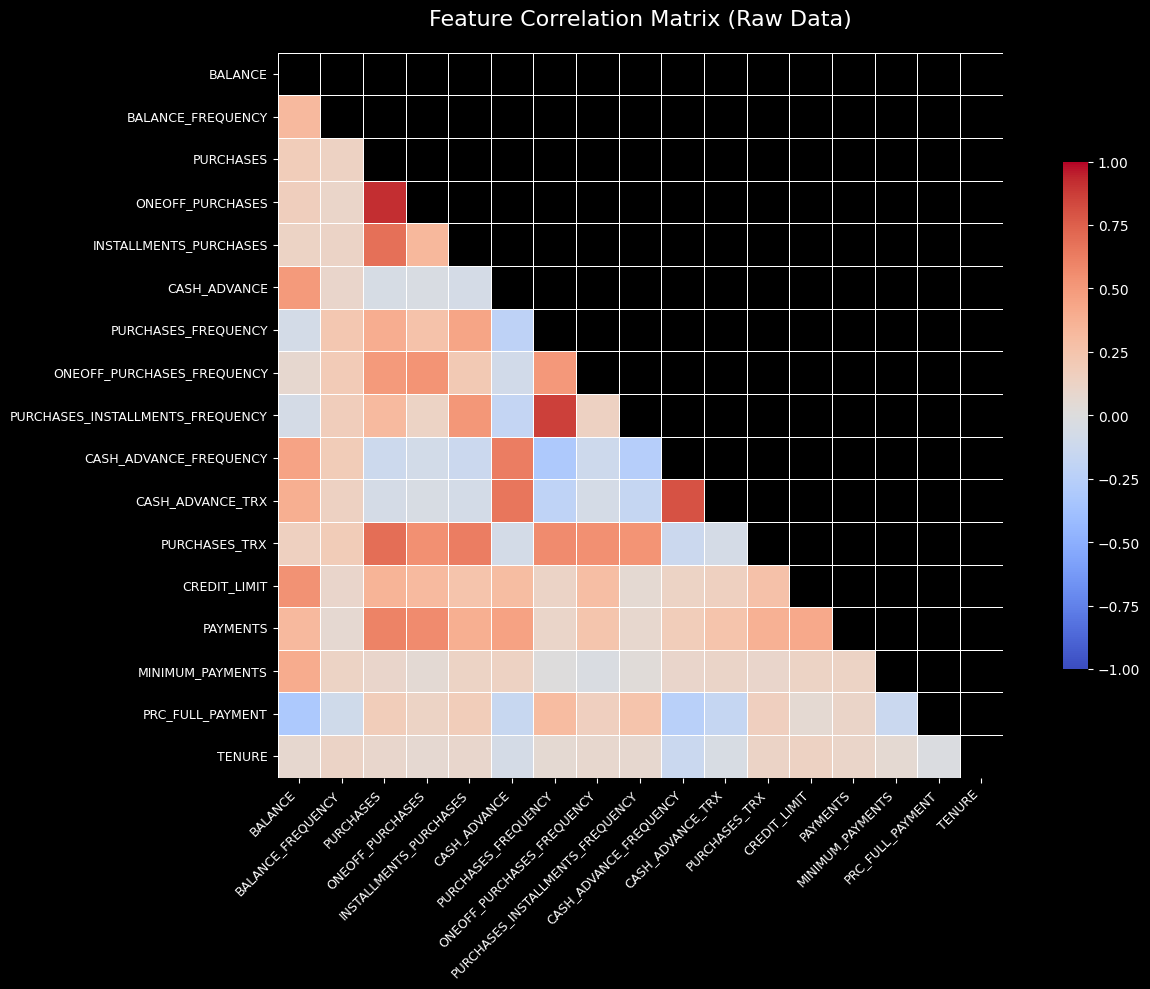


--- Distribution Metrics (Skewness & Kurtosis) ---


,Skewness,Kurtosis
BALANCE,2.39,7.67
PURCHASES,8.14,111.39
CASH_ADVANCE,5.17,52.90
CREDIT_LIMIT,1.52,2.84


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


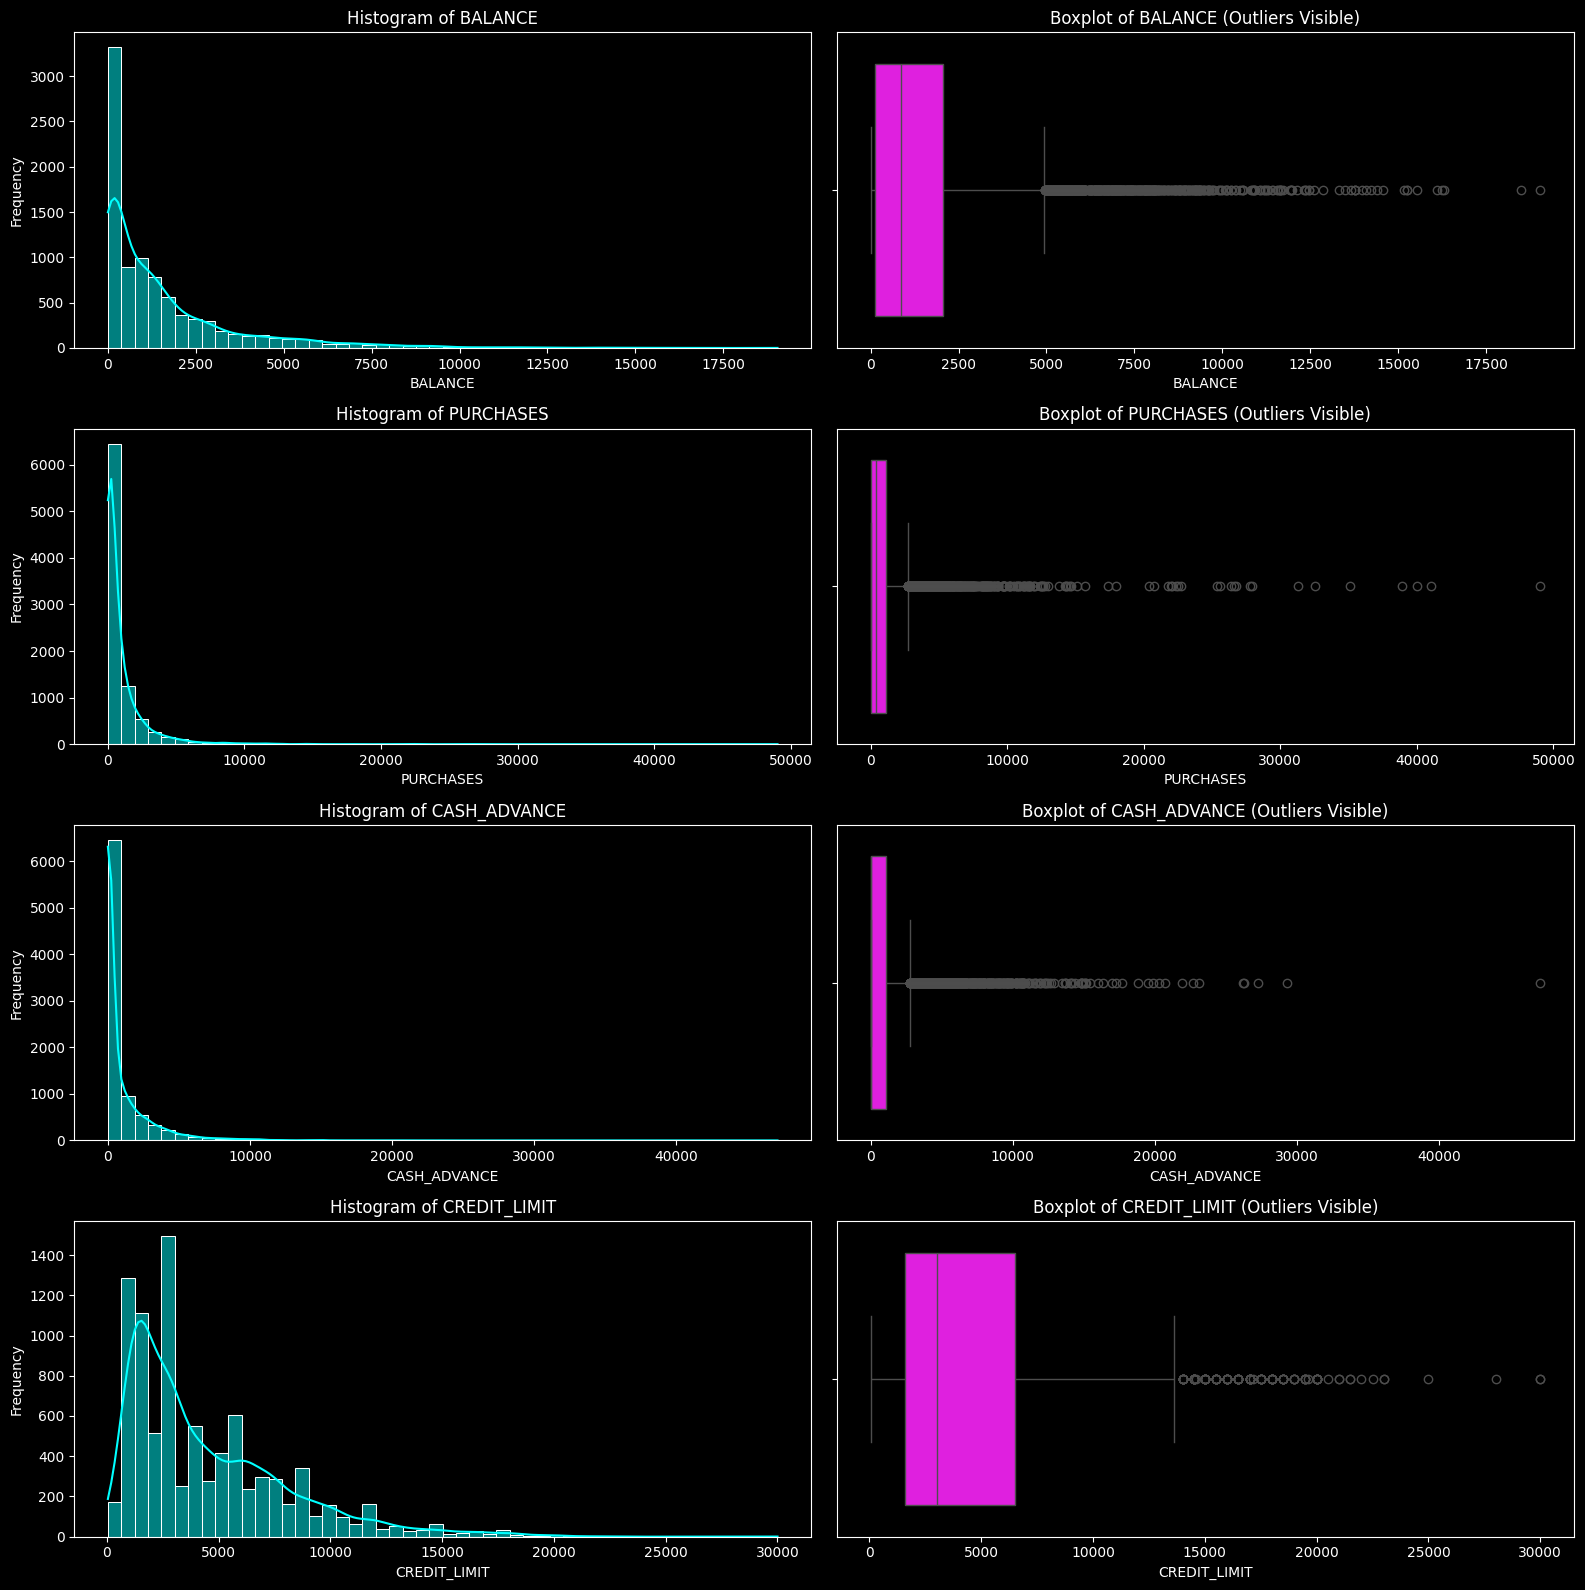

In [83]:
# =============================================
# ==================== Q 2  =====================
# =============================================

print("--- 2.1 Structural Analysis (Raw Data) ---")
print(f"Shape of Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

print("\nMissing Values per column (Raw Data):")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Expose the missing values explicitly

print("\nData Types:\n", df.dtypes.value_counts().to_string())

# --- Statistical Summary ---
print("\n--- Statistical Summary (Raw Data) ---")
# Using .describe() and Transposing (.T) for a cleaner Colab console output
display(df.describe().T)
print("-" * 247)

# --- Correlation Matrix ---
# Exclude the string/object column (CUST_ID) dynamically to prevent correlation math errors
numeric_df = df.select_dtypes(include=[np.number])

plt.style.use('dark_background')
plt.figure(figsize=(14, 10))
corr_matrix = numeric_df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=1, vmin=-1,
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title('Feature Correlation Matrix (Raw Data)', fontsize=16, pad=20)
plt.tick_params(colors='white', which='both')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# --- 2.2 & 2.3 Distribution & Outlier Analysis ---
# Selecting the 4 major features logically driving customer behavior
major_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

print("\n--- Distribution Metrics (Skewness & Kurtosis) ---")
stats_df = pd.DataFrame({
    'Skewness': numeric_df[major_features].skew(),
    'Kurtosis': numeric_df[major_features].kurtosis()
})
display(stats_df.round(2))
print("-" * 320)

# Plotting Histograms and Boxplots for the major features
fig, axes = plt.subplots(nrows=len(major_features), ncols=2, figsize=(16, 4 * len(major_features)))

for i, feature in enumerate(major_features):
    # Drop missing values only for plotting
    sns.histplot(df[feature].dropna(), bins=50, kde=True, color='cyan', ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {feature}', color='white')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].tick_params(colors='white', which='both')

    # Boxplot
    sns.boxplot(x=df[feature].dropna(), color='magenta', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {feature} (Outliers Visible)', color='white')
    axes[i, 1].tick_params(colors='white', which='both')

plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis

To understand the underlying geometry and behavioral patterns of the raw dataset before applying unsupervised learning models, I conducted a comprehensive exploratory data analysis based strictly on the raw data output.

### Structural Analysis

* **Number of rows and columns:** The dataset consists of 8,950 rows (customer records) and 18 columns (features).
* **Missing values:** An inspection of the raw data revealed missing values in two specific columns: `MINIMUM_PAYMENTS` contains 313 null values, and `CREDIT_LIMIT` contains 1 null value.
* **Data types:** The dataset is predominantly numeric, comprising 14 continuous features (`float64`), 3 discrete count features (`int64`), and exactly 1 categorical feature (`object`) which serves as the unique `CUST_ID`.
* **Statistical summary:** The descriptive statistics reveal massive divergence between the median (50th percentile) and the mean across monetary features. For example, the median `PURCHASES` is approximately \$361, yet the mean is severely pulled upwards to \$1,003 due to an extreme maximum value of \$49,039. This suggests a strong right-skew, which is also supported by the skewness values.
* **Correlation matrix:** The heatmap highlights some clear relationships between the features. For example, `PURCHASES` has a very strong positive correlation with `ONEOFF_PURCHASES` and `PURCHASES_TRX`. This simply means that customers with high total purchase amounts usually make frequent, single transactions rather than paying in installments. On the other hand, the `CASH_ADVANCE` features have almost zero correlation with the regular shopping features. This suggests two main behavior patterns in the dataset: customers who use the card mainly for shopping, and customers who use it to pull out cash.

### Distribution Analysis

For the major features driving customer behavior (`BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`), the analysis shows:

* **Histogram:** The histograms for all four major features demonstrate an extreme right-skewed curve. The vast majority of observations are heavily concentrated near the zero-bound (left side), with frequency dropping exponentially as the monetary values increase.
* **Boxplot:** The corresponding boxplots visually confirm this distribution. The interquartile range (the pink boxes representing the middle 50% of users) is exceptionally narrow and compressed to the left, while an extended trail of individual data points (outliers) stretches far beyond the upper whiskers to the right.
* **Skewness:** The data is highly asymmetrical. Calculated skewness confirms the rightward pull: `PURCHASES` (8.14), `CASH_ADVANCE` (5.17), `BALANCE` (2.39), and `CREDIT_LIMIT` (1.52).
* **Kurtosis:** The kurtosis values highlight the extremity of the tails compared to a normal distribution. `PURCHASES` presents an astronomical kurtosis of 111.39, and `CASH_ADVANCE` sits at 52.90, mathematically proving that these features are completely dominated by their heavy tails.

### Outlier Exploration

* **Heavy tails:** As proven by the extreme kurtosis metrics (e.g., 111.39 for purchases) and the density plots, the dataset is defined by its heavy rightward tails.
* **Extreme values:** The boxplots explicitly highlight these extreme values as individual circles extending far beyond standard variances. A maximum `BALANCE` of \$19,000 and maximum `PURCHASES` of \$49,000 represent the absolute extremes of this behavioral spectrum.
* **Possible noise, Measurement artifacts, and Data-entry problems:** In many scientific domains (such as IoT or sensor arrays), extreme variance of this magnitude usually indicates measurement artifacts, sensor noise, or data-entry errors. However, applying critical domain knowledge to financial credit systems alters this conclusion. A \$19,000 credit card balance is not a data-entry problem; it represents a statistically valid, real-world user in severe debt or a high-net-worth individual making massive transactions. Because these extreme values represent genuine consumer behavior rather than systemic noise, they must not be clipped or removed. I kept these values in the dataset because they may represent meaningful rare behavior, and they will be used in the anomaly detection section.


In [84]:
# =============================================
# =========== Data Preprocessing ==============
# =============================================

df_clean = df.copy() # copy the raw dataframe

if 'CUST_ID' in df_clean.columns:
    df_clean = df_clean.drop('CUST_ID', axis=1) # drop non-numeric id column

# handle missing values using median (due to extreme outliers)
imputer = SimpleImputer(strategy='median')
df_clean = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns) # fill missing values with median

print("✅ Missing values handled and CUST_ID dropped.")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
display(df_clean.head()) # display the cleaned data in its original format

✅ Missing values handled and CUST_ID dropped.
Missing values remaining: 0


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


**Data Preprocessing & Cleaning**

To prepare the dataset for the next stages, I performed two key preprocessing steps. First, I removed the CUST_ID column, as it is a unique string identifier with no mathematical value that would interfere with distance-based calculations. Second, I addressed missing values using median imputation; because financial data is heavily skewed and contains extreme outliers, using the mean would distort the distribution. This resulted in a clean, fully numeric dataset.

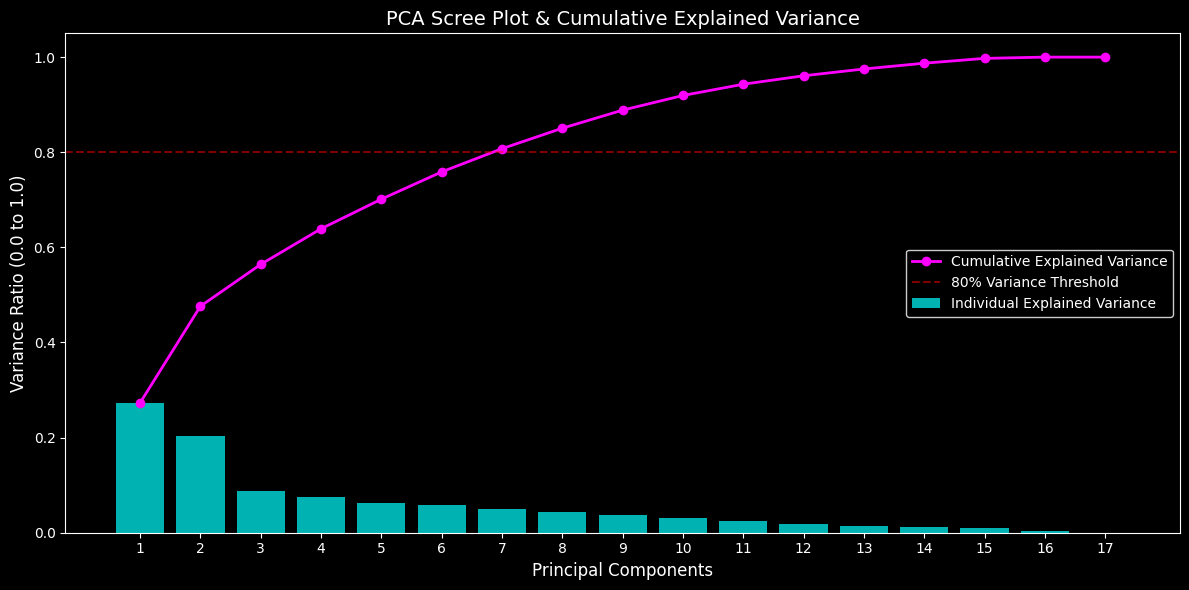


--- PCA Variance Metrics ---
PC1: 27.30% variance (Cumulative: 27.30%)
PC2: 20.31% variance (Cumulative: 47.61%)
PC3: 8.81% variance (Cumulative: 56.42%)
PC4: 7.48% variance (Cumulative: 63.90%)
PC5: 6.22% variance (Cumulative: 70.13%)
PC6: 5.74% variance (Cumulative: 75.87%)
PC7: 4.88% variance (Cumulative: 80.75%)

✅ Reached 80% variance threshold at Principal Component 7

--- Generating 2D & 3D Projections ---


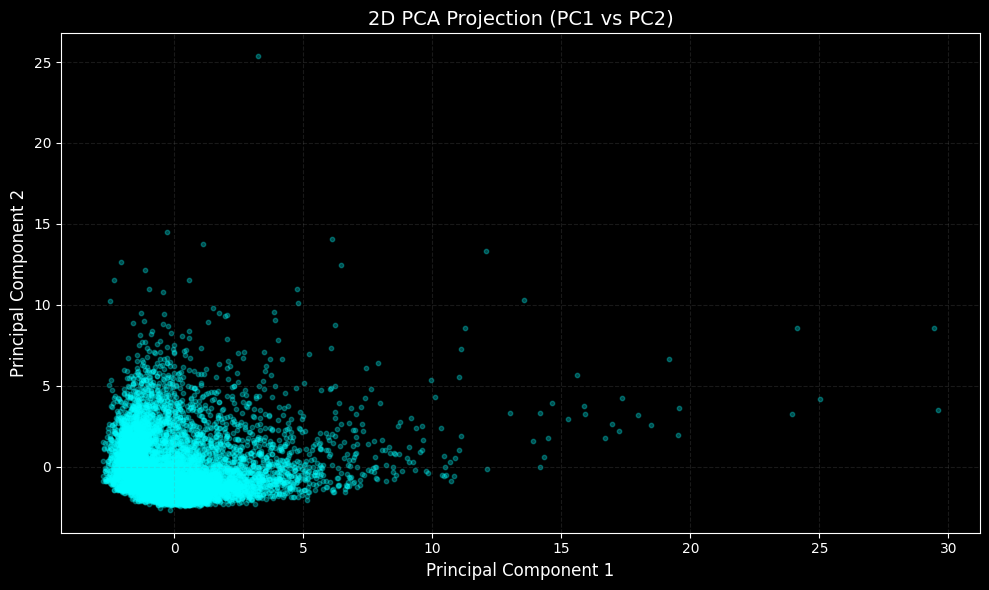

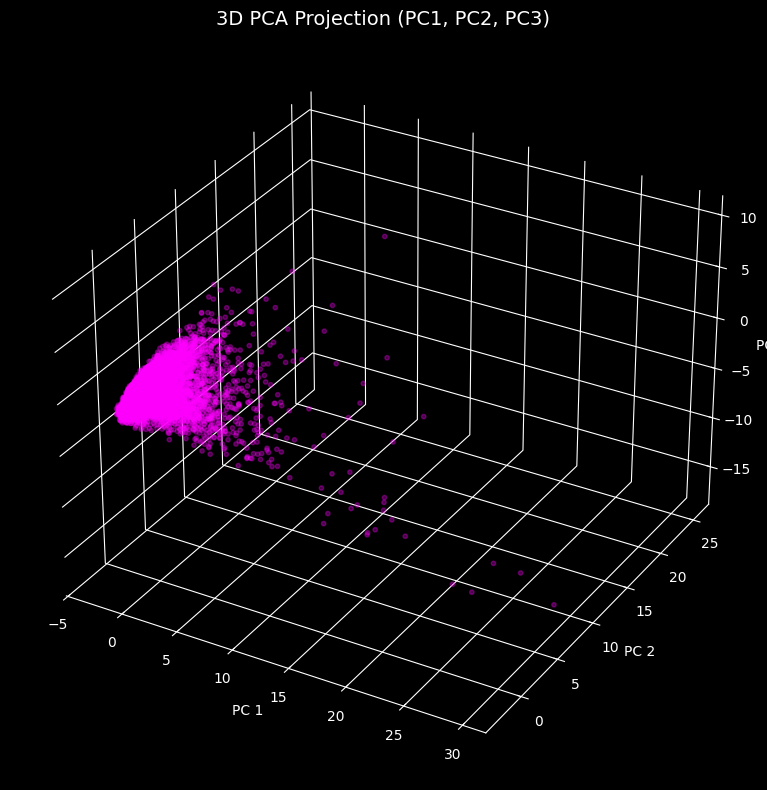

In [85]:
# =============================================
# ==================== Q 3.1 ====================
# =============================================

# --- PART 1: PCA Fitting and Variance Analysis ---

# 1. # Scale the data before PCA so all features have comparable weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean) # scale the clean data so all columns have equal weight
df_scaled_fixed = pd.DataFrame(X_scaled, columns=df_clean.columns)

# 2. Fit the PCA
pca_full = PCA()
pca_full.fit(df_scaled_fixed) # compute PCs on scaled data

exp_var_ratio = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

# 3. Scree plot with cumulative explained variance
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.7, color='cyan', label='Individual Explained Variance')
plt.plot(range(1, len(cum_exp_var) + 1), cum_exp_var, marker='o', linestyle='-', color='magenta', linewidth=2, label='Cumulative Explained Variance')

# Add a reference line at 80% variance
plt.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='80% Variance Threshold')

# Set the y-axis range slightly above 1 for readability
plt.ylim([0, 1.05])
plt.ylabel('Variance Ratio (0.0 to 1.0)', color='white', fontsize=12)
plt.xlabel('Principal Components', color='white', fontsize=12)
plt.xticks(range(1, len(exp_var_ratio) + 1))
plt.tick_params(colors='white', which='both')

plt.legend(loc='center right', facecolor='black', edgecolor='white', labelcolor='white')
plt.title('PCA Scree Plot & Cumulative Explained Variance', color='white', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Print the exact numbers and dynamically find the 80% threshold
print("\n--- PCA Variance Metrics ---")
components_needed = 0

for i in range(len(exp_var_ratio)):
    print(f"PC{i+1}: {exp_var_ratio[i]*100:.2f}% variance (Cumulative: {cum_exp_var[i]*100:.2f}%)")

    # Check if we just crossed the 80% threshold
    if cum_exp_var[i] >= 0.80 and components_needed == 0:
        components_needed = i + 1
        print(f"\n✅ Reached 80% variance threshold at Principal Component {components_needed}")
        break # Stop after reaching the threshold

# --- PART 2: 2D & 3D Projections ---
print("\n--- Generating 2D & 3D Projections ---")

# 5. Project the scaled data into the principal component space
X_pca = pca_full.transform(df_scaled_fixed)

# Extract the first 3 components for visualization
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]
pc3 = X_pca[:, 2]

# 6. 2D Projection
plt.figure(figsize=(10, 6))
plt.scatter(pc1, pc2, alpha=0.3, color='cyan', s=10) # plot pc1 vs pc2 with low alpha to see density
plt.title('2D PCA Projection (PC1 vs PC2)', color='white', fontsize=14)
plt.xlabel('Principal Component 1', color='white', fontsize=12)
plt.ylabel('Principal Component 2', color='white', fontsize=12)
plt.tick_params(colors='white', which='both')
plt.grid(color='gray', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

# 7. 3D Projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configure dark background for 3D axes
ax.set_facecolor('black')
ax.xaxis.set_pane_color((0.0, 0.0, 0.0, 1.0))
ax.yaxis.set_pane_color((0.0, 0.0, 0.0, 1.0))
ax.zaxis.set_pane_color((0.0, 0.0, 0.0, 1.0))

# Plot 3D scatter
ax.scatter(pc1, pc2, pc3, alpha=0.3, color='magenta', s=10)

ax.set_title('3D PCA Projection (PC1, PC2, PC3)', color='white', fontsize=14)
ax.set_xlabel('PC 1', color='white')
ax.set_ylabel('PC 2', color='white')
ax.set_zlabel('PC 3', color='white')
ax.tick_params(colors='white', which='both')

plt.tight_layout()
plt.show()

### 3 (3.1) Principal Component Analysis (PCA)

Following the application of Principal Component Analysis (PCA) on the standardized 17-dimensional dataset, I analyzed the variance metrics and geometric projections to understand the data's underlying structure.

**Dimensionality Reduction & Variance Analysis**

* **Explained variance ratio & Cumulative explained variance:** As extracted from the model and visualized in the Scree plot, each principal component accounts for a specific ratio of the original dataset's total variance. For instance, the explained variance ratio of PC1 is 27.30%, and PC2 is 20.31%. The cumulative explained variance tracks the running total of retained information, providing a quantitative metric to decide when to stop adding dimensions.
* **How many components are needed:** To strike a balance between dimensionality reduction and information retention, an 80% explained variance threshold was established. Based on the cumulative variance metrics, **7 principal components** are required to surpass this threshold (reaching exactly 80.75%). This allows me to reduce the feature space by over 40% (discarding 10 dimensions) while maintaining the structural integrity of the dataset.
* **Information loss:** Visualizing the data necessitates severe compression, leading to substantial information loss. The 2D projection (PC1 and PC2) accounts for only 47.61% of the original variance, meaning more than 52% of the dataset's behavioral variance is completely lost. Even the 3D projection (adding PC3) captures only 56.42%. Consequently, visual proximity in these plots does not guarantee true multidimensional similarity.
* **Correlated variables:** The steep initial descent in the Scree plot indicates significant collinearity among the original 17 features. The fact that PC1 alone captures 27.30% of the variance proves that the algorithm successfully collapsed overlapping, highly correlated variables (such as various purchasing frequencies and amounts) into unified mathematical representations.
* **Interpretation of major components:**
    * **PC1 (27.30%):** Represents the direction of maximum variance, heavily influenced by the extreme positive values stretching along the x-axis in the projections. This likely corresponds to overall "Transaction Volume" or magnitude.
    * **PC2 (20.31%):** Represents the secondary behavioral axis (the y-axis spread), likely distinguishing between different strategies of credit utilization, such as standard retail purchasing versus heavy cash-advance withdrawals.

**Methodological Discussion**

* **Local vs global structure:** PCA is a linear algorithm designed to maximize variance, meaning it inherently prioritizes the **global structure** of the data. As seen in the projections, PCA successfully highlights the macroscopic spread and the extreme outliers stretching the axes. However, it crushes the **local structure**; the massive, dense core of standard customers is squashed into a tight blob near the origin, obscuring the local neighborhood relationships within that dense region.
* **Cluster separation:** The 2D and 3D scatter plots reveal that the data does not naturally separate into distinct, spherical, or isolated clusters. Instead, it forms a single highly dense central core with continuous, heavy-tailed distributions extending outward. PCA merely rotates the data to show this variance; it does not optimize for class separability.
* **Stability:** PCA relies on Singular Value Decomposition (SVD), making it a deterministic and highly stable algorithm. Unlike stochastic methods (e.g., K-Means initialization or t-SNE), it gives stable results when the same data and preprocessing are used. However, it is fundamentally sensitive to the scaling of the data and the presence of extreme outliers, which heavily dictate the direction of the eigenvectors.
* **Computational cost:** The computational cost of PCA is highly efficient, generally scaling as $O(min(n, d)^3)$. For a dataset of approximately 8,950 rows and 17 dimensions, the computation is near-instantaneous, making it an excellent preprocessing step before applying heavier clustering algorithms.
* **Interpretability:** Geometrically, PCA is perfectly interpretable as a rigid rotation of axes. Mathematically, the exact weights (loadings) of each original feature in the new components are known. However, practically, the new components (PC1, PC2) are abstract linear combinations, making them slightly less intuitive compared to the original raw features.


--- Evaluate: K-Means ---
Number of Clusters: 4
Noise Points: 0
Cluster Sizes:
        Cluster 0: 3977 samples
        Cluster 1: 409 samples
        Cluster 2: 1197 samples
        Cluster 3: 3367 samples
Global Variance: 17.00
Avg Intra-Cluster Variance: 21.86
Weighted Intra-Cluster Variance: 11.07
Silhouette Score: 0.1977

--- Evaluate: DBSCAN ---
Number of Clusters: 2
Noise Points: 55
Cluster Sizes:
        Cluster 0: 8890 samples
        Cluster 1: 5 samples
Global Variance: 14.29
Avg Intra-Cluster Variance: 11.69
Weighted Intra-Cluster Variance: 14.13
Silhouette Score: 0.7182

--- Evaluate: Hierarchical Clustering ---
Number of Clusters: 4
Noise Points: 0
Cluster Sizes:
        Cluster 0: 4875 samples
        Cluster 1: 300 samples
        Cluster 2: 1194 samples
        Cluster 3: 2581 samples
Global Variance: 17.00
Avg Intra-Cluster Variance: 23.87
Weighted Intra-Cluster Variance: 12.05
Silhouette Score: 0.1598

--- Clustering Summary Table ---


,Model,Clusters,Noise Points,Global Variance,Avg Intra-Cluster Variance,Weighted Intra-Cluster Variance,Silhouette Score
0,K-Means,4,0,17.000000,21.862560,11.068373,0.197679
1,DBSCAN,2,55,14.287187,11.691998,14.127370,0.718243
2,Hierarchical Clustering,4,0,17.000000,23.865675,12.053902,0.159784


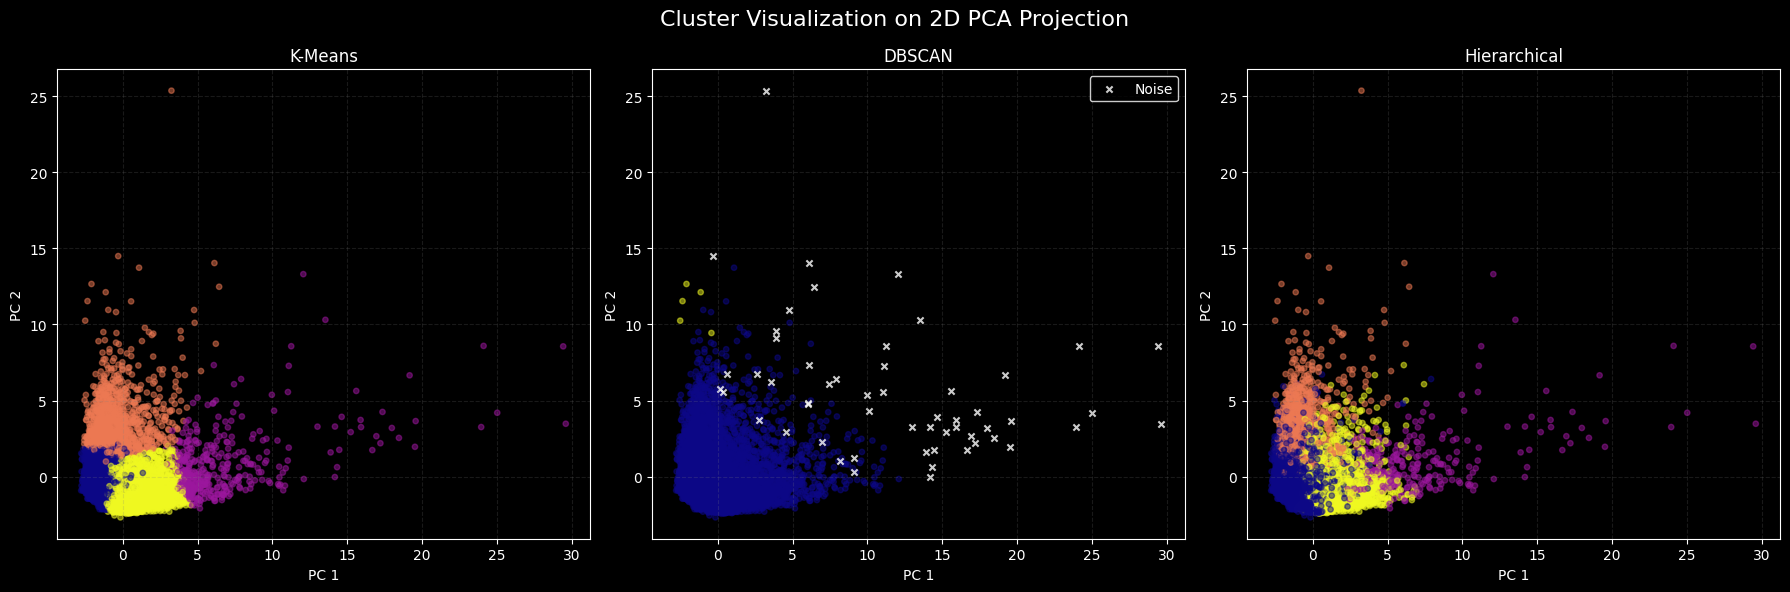


--- Clustering on the Feature Space ---


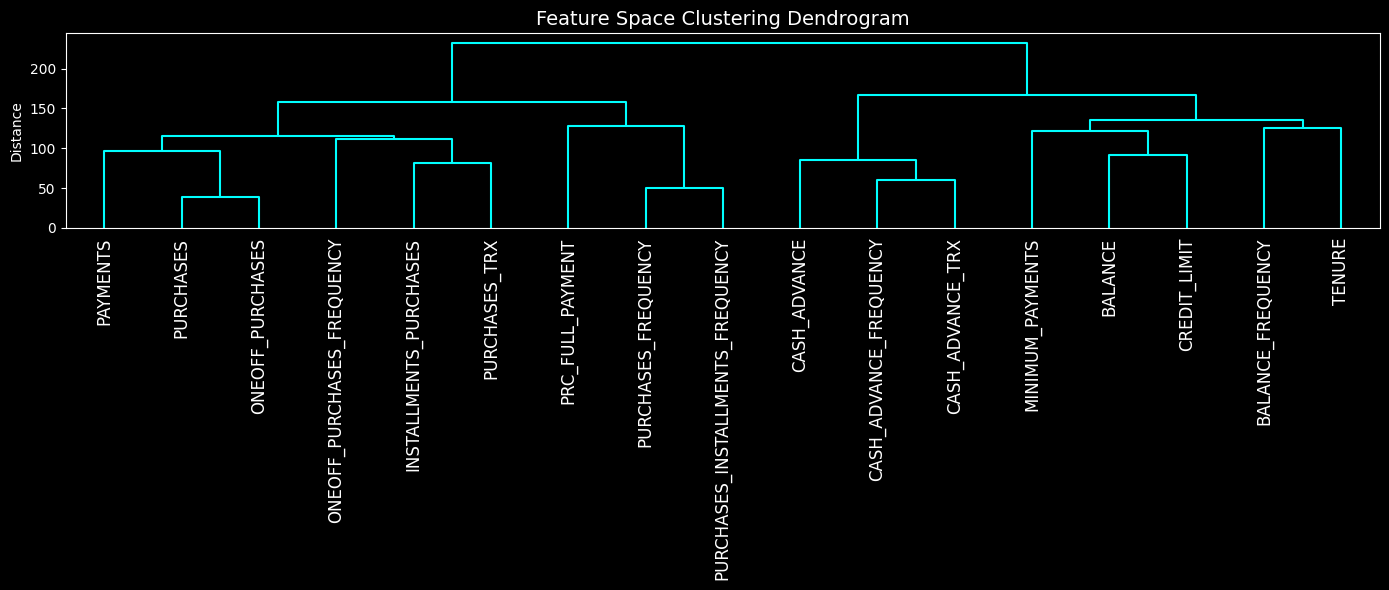


--- Feature Cluster Groups ---

Feature Cluster 1:
  - ONEOFF_PURCHASES
  - PURCHASES
  - ONEOFF_PURCHASES_FREQUENCY
  - INSTALLMENTS_PURCHASES
  - PAYMENTS
  - PURCHASES_TRX

Feature Cluster 2:
  - PURCHASES_FREQUENCY
  - PRC_FULL_PAYMENT
  - PURCHASES_INSTALLMENTS_FREQUENCY

Feature Cluster 3:
  - CASH_ADVANCE_TRX
  - CASH_ADVANCE
  - CASH_ADVANCE_FREQUENCY

Feature Cluster 4:
  - BALANCE_FREQUENCY
  - BALANCE
  - CREDIT_LIMIT
  - MINIMUM_PAYMENTS
  - TENURE


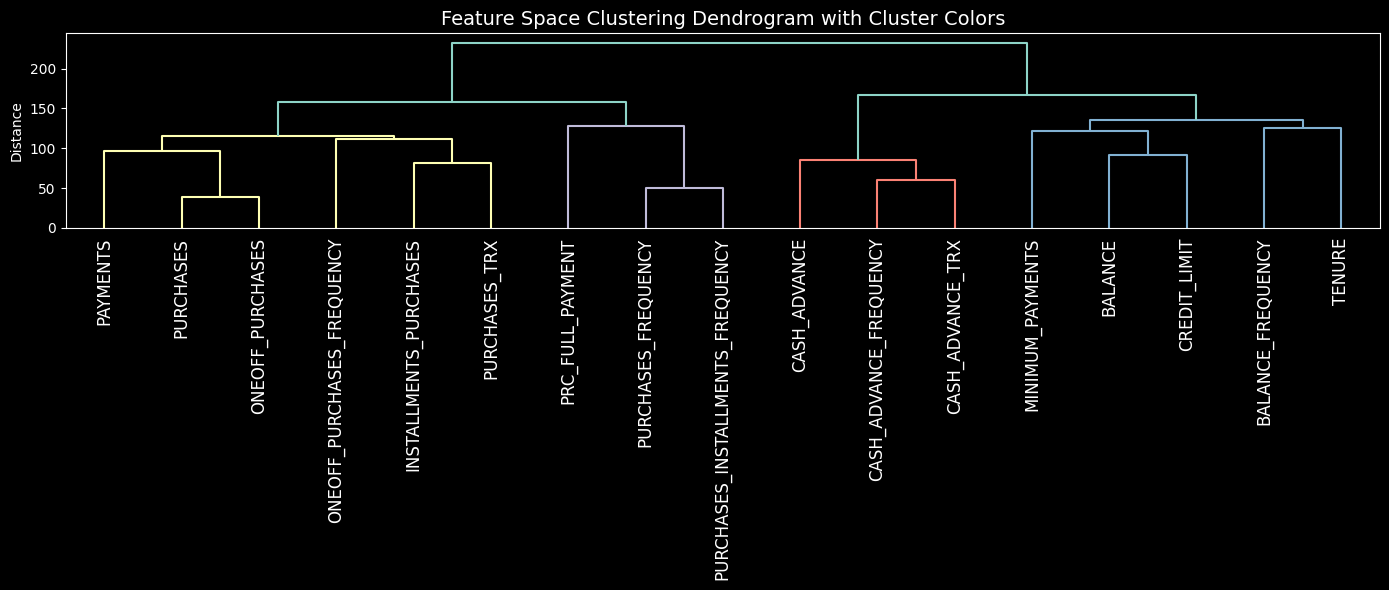

In [86]:
# =============================================
# ========= Q 4: Clustering Analysis ==========
# =============================================

plt.style.use('dark_background')

# ---------------------------------------------------------
# Function for evaluating clustering results
# ---------------------------------------------------------
def evaluate_clustering(X, labels, model_name):
    labels = np.array(labels)

    # DBSCAN may label some points as noise using -1
    valid_mask = labels != -1
    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]

    unique_clusters = np.unique(labels_valid)
    n_clusters = len(unique_clusters)
    noise_points = np.sum(labels == -1)

    print(f"\n--- Evaluate: {model_name} ---")
    print(f"Number of Clusters: {n_clusters}")
    print(f"Noise Points: {noise_points}")

    print("Cluster Sizes:")
    for cluster_id in unique_clusters:
        print(f"        Cluster {cluster_id}: {np.sum(labels_valid == cluster_id)} samples")

    if n_clusters < 2:
        print("Less than 2 valid clusters found. Metrics cannot be computed.")
        return {
            "Model": model_name,
            "Clusters": n_clusters,
            "Noise Points": noise_points,
            "Global Variance": None,
            "Avg Intra-Cluster Variance": None,
            "Weighted Intra-Cluster Variance": None,
            "Silhouette Score": None
        }

    # Variance of the full data after removing noise points
    global_var = np.var(X_valid, axis=0).sum()

    # Variance inside each cluster
    cluster_vars = []
    cluster_sizes = []

    for cluster_id in unique_clusters:
        cluster_data = X_valid[labels_valid == cluster_id]
        cluster_var = np.var(cluster_data, axis=0).sum()
        cluster_vars.append(cluster_var)
        cluster_sizes.append(len(cluster_data))

    avg_cluster_var = np.mean(cluster_vars)
    weighted_cluster_var = np.average(cluster_vars, weights=cluster_sizes)

    try:
        sil_score = silhouette_score(X_valid, labels_valid)
    except:
        sil_score = None

    print(f"Global Variance: {global_var:.2f}")
    print(f"Avg Intra-Cluster Variance: {avg_cluster_var:.2f}")
    print(f"Weighted Intra-Cluster Variance: {weighted_cluster_var:.2f}")

    if sil_score is not None:
        print(f"Silhouette Score: {sil_score:.4f}")
    else:
        print("Silhouette Score: Could not be computed")

    return {
        "Model": model_name,
        "Clusters": n_clusters,
        "Noise Points": noise_points,
        "Global Variance": global_var,
        "Avg Intra-Cluster Variance": avg_cluster_var,
        "Weighted Intra-Cluster Variance": weighted_cluster_var,
        "Silhouette Score": sil_score
    }


# ---------------------------------------------------------
# Clustering on samples
# ---------------------------------------------------------

results = []

X_clustering = df_scaled_fixed.values

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clustering)
results.append(evaluate_clustering(X_clustering, kmeans_labels, "K-Means"))

# DBSCAN
dbscan = DBSCAN(eps=5.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_clustering)
results.append(evaluate_clustering(X_clustering, dbscan_labels, "DBSCAN"))

# Hierarchical clustering
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_clustering)
results.append(evaluate_clustering(X_clustering, agglo_labels, "Hierarchical Clustering"))


# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------

summary_df = pd.DataFrame(results)

print("\n--- Clustering Summary Table ---")
display(summary_df)


# ---------------------------------------------------------
# Cluster visualization on PCA projection
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cluster Visualization on 2D PCA Projection', color='white', fontsize=16)

models = {
    'K-Means': kmeans_labels,
    'DBSCAN': dbscan_labels,
    'Hierarchical': agglo_labels
}

for ax, (title, labels) in zip(axes, models.items()):
    labels = np.array(labels)

    non_noise_mask = labels != -1

    ax.scatter(
        pc1[non_noise_mask],
        pc2[non_noise_mask],
        c=labels[non_noise_mask],
        cmap='plasma',
        alpha=0.5,
        s=15
    )

    if np.any(labels == -1):
        ax.scatter(
            pc1[labels == -1],
            pc2[labels == -1],
            color='white',
            alpha=0.8,
            s=20,
            marker='x',
            label='Noise'
        )
        ax.legend(facecolor='black', edgecolor='white', labelcolor='white')

    ax.set_title(title, color='white')
    ax.set_xlabel('PC 1', color='white')
    ax.set_ylabel('PC 2', color='white')
    ax.tick_params(colors='white')
    ax.grid(color='gray', linestyle='--', alpha=0.2)
    ax.set_facecolor('black')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Clustering on the feature space
# ---------------------------------------------------------

print("\n--- Clustering on the Feature Space ---")

# Transpose the scaled data so each row represents a feature
X_features = df_scaled_fixed.T

# Build hierarchical clustering structure for the features
linkage_matrix_features = sch.linkage(X_features, method='ward')

# Basic dendrogram with one color
plt.figure(figsize=(14, 6))
sch.dendrogram(
    linkage_matrix_features,
    labels=X_features.index,
    leaf_rotation=90,
    leaf_font_size=12,
    link_color_func=lambda k: 'cyan'
)

plt.title('Feature Space Clustering Dendrogram', color='white', fontsize=14)
plt.ylabel('Distance', color='white')
plt.tick_params(colors='white', which='both')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Feature cluster groups
# ---------------------------------------------------------

n_feature_clusters = 4

feature_cluster_labels = sch.fcluster(
    linkage_matrix_features,
    t=n_feature_clusters,
    criterion='maxclust'
)

feature_clusters = pd.DataFrame({
    "Feature": X_features.index,
    "Feature Cluster": feature_cluster_labels
}).sort_values(by="Feature Cluster")

print("\n--- Feature Cluster Groups ---")

for cluster_id in sorted(feature_clusters["Feature Cluster"].unique()):
    features_in_cluster = feature_clusters[
        feature_clusters["Feature Cluster"] == cluster_id
    ]["Feature"].tolist()

    print(f"\nFeature Cluster {cluster_id}:")
    for feature in features_in_cluster:
        print(f"  - {feature}")


# ---------------------------------------------------------
# Feature dendrogram with cluster colors
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

sch.dendrogram(
    linkage_matrix_features,
    labels=X_features.index,
    leaf_rotation=90,
    leaf_font_size=12,
    color_threshold=linkage_matrix_features[-(n_feature_clusters - 1), 2]
)

plt.title('Feature Space Clustering Dendrogram with Cluster Colors', color='white', fontsize=14)
plt.ylabel('Distance', color='white')
plt.tick_params(colors='white', which='both')
plt.tight_layout()
plt.show()

# 4. Clustering Analysis

## Clustering on the Feature Space

### What information can be obtained by clustering the features?

Feature-space clustering groups together variables that behave similarly across the dataset. Instead of discovering groups of customers, it reveals relationships between the variables themselves. This allows us to identify correlations, dependencies, and common behavioral patterns among financial indicators.

### Did the analysis reveal groups of related or redundant features?

Yes. The hierarchical clustering revealed several meaningful feature groups:

**Feature Cluster 1 – Purchase Activity**

* ONEOFF_PURCHASES
* PURCHASES
* ONEOFF_PURCHASES_FREQUENCY
* INSTALLMENTS_PURCHASES
* PAYMENTS
* PURCHASES_TRX

These variables all describe customer purchasing behavior and transaction activity.

**Feature Cluster 2 – Purchase Frequency and Repayment Behavior**

* PURCHASES_FREQUENCY
* PRC_FULL_PAYMENT
* PURCHASES_INSTALLMENTS_FREQUENCY

These features are related to how frequently customers use their credit cards and how consistently they repay their balances.

**Feature Cluster 3 – Cash Advance Behavior**

* CASH_ADVANCE
* CASH_ADVANCE_TRX
* CASH_ADVANCE_FREQUENCY

This cluster is particularly strong because all three variables describe different aspects of the same underlying behavior: cash withdrawal activity. Their close grouping suggests substantial redundancy.

**Feature Cluster 4 – Account and Credit Characteristics**

* BALANCE
* BALANCE_FREQUENCY
* CREDIT_LIMIT
* MINIMUM_PAYMENTS
* TENURE

These variables describe account status, credit exposure, repayment obligations, and customer longevity.

### Were there features that appeared isolated or significantly different from the others?

No feature appeared completely isolated. However, the feature clustering clearly separated purchasing behavior, cash-advance behavior, and account-credit characteristics into distinct groups. This indicates that these behaviors represent different dimensions of customer activity.

### Did this analysis provide insights that were not visible when clustering the samples directly?

Yes. Sample clustering focuses on grouping customers, while feature clustering reveals relationships between variables. For example, the strong grouping of the cash-advance variables and the separation between spending behavior and account-credit characteristics become much more apparent when clustering the features themselves.

### In what types of problems or domains might clustering features be particularly useful?

Feature clustering is especially useful in high-dimensional datasets where many variables may contain overlapping information. Examples include:

* Bioinformatics (gene expression analysis)
* Finance (customer behavior modeling)
* Recommendation systems
* Natural language processing
* Sensor and IoT data analysis

It can help reduce dimensionality, identify redundant variables, and improve feature selection.

### Did clustering the feature space uncover hidden structure, dependencies, correlations, or feature hierarchies?

Yes. The dendrogram revealed a hierarchical organization of the variables. Related features merged at low linkage distances, while unrelated groups merged only at much higher distances. This exposed meaningful dependencies and behavioral hierarchies within the dataset that were not immediately visible from the raw data.

## Required Analysis

### 1. K-Means

#### Mathematical Intuition

K-Means partitions the data into (k) clusters by minimizing the within-cluster sum of squared distances. The algorithm repeatedly assigns observations to the nearest centroid and updates centroid locations until convergence.

#### Assumptions

* Clusters are approximately spherical.
* Clusters have similar variance.
* Clusters have roughly similar sizes.
* The number of clusters is known in advance.

#### Strengths

* Fast and computationally efficient.
* Scales well to large datasets.
* Easy to implement and interpret.

#### Weaknesses

* Requires a predefined number of clusters.
* Sensitive to outliers.
* Performs poorly when clusters have irregular shapes.

### 2. DBSCAN

#### Mathematical Intuition

DBSCAN identifies clusters as dense regions of points separated by lower-density regions. Points that do not belong to any dense region are labeled as noise.

#### Assumptions

* Clusters correspond to dense regions.
* Meaningful density differences exist between clusters and noise.

#### Strengths

* Does not require specifying the number of clusters.
* Detects outliers automatically.
* Can identify arbitrarily shaped clusters.

#### Weaknesses

* Sensitive to hyperparameter selection.
* Often struggles in high-dimensional spaces.
* Density differences between clusters may reduce performance.

### 3. Hierarchical Clustering (Agglomerative)

#### Mathematical Intuition

Hierarchical clustering follows a bottom-up approach. Each observation initially forms its own cluster. The algorithm repeatedly merges the closest clusters until a hierarchical tree structure is formed.

#### Assumptions

* The data contains a meaningful hierarchical structure.
* Similar observations should merge earlier than dissimilar observations.

#### Strengths

* Produces an interpretable dendrogram.
* Useful for exploring hierarchical relationships.
* Does not require specifying cluster centers.

#### Weaknesses

* Computationally expensive for large datasets.
* Early merge decisions cannot be reversed.
* Final results depend on the selected cut level.

## Evaluation

The assignment suggests comparing the **Global Variance** and the **Average Intra-Cluster Variance**.

### Is this metric suitable?

The metric provides useful information about cluster compactness, but it should not be used as the sole measure of clustering quality.

One limitation is that the average intra-cluster variance can be strongly affected by cluster size distribution. Small clusters containing highly dispersed observations may inflate the average variance and lead to misleading conclusions.

### Alternative Metric: Silhouette Score

The Silhouette Score evaluates both:

* **Cohesion** – how similar observations are to points within the same cluster.
* **Separation** – how different observations are from points in other clusters.

Because it measures both compactness and separation, it provides a more reliable assessment of clustering quality.

### Results

| Algorithm               | Clusters | Noise Points | Silhouette Score |
| ----------------------- | -------- | ------------ | ---------------- |
| K-Means                 | 4        | 0            | 0.1977           |
| Hierarchical Clustering | 4        | 0            | 0.1598           |
| DBSCAN                  | 2        | 55           | 0.7182           |

The K-Means and Hierarchical methods produced relatively low Silhouette Scores, indicating substantial overlap between clusters and weak separation.

DBSCAN achieved a much higher Silhouette Score. However, a closer inspection shows that it identified one dominant cluster containing 8,890 observations, a very small secondary cluster containing only 5 observations, and 55 noise points. Therefore, the high score reflects the existence of a dense core and isolated outliers rather than multiple well-separated customer segments.

## Visualization

The PCA projections provide a visual comparison of the clustering results.

* **K-Means** partitions the dense customer population into four geometric groups.
* **Hierarchical Clustering** produces a similar partitioning pattern with slightly weaker separation.
* **DBSCAN** identifies one dominant dense region and classifies sparse observations as noise.

The visualizations are consistent with the Silhouette Scores obtained during evaluation.

## Discussion

### Why do different algorithms produce different clusters?

Each algorithm defines a cluster differently.

K-Means and Hierarchical Clustering are distance-based methods that attempt to group nearby observations together. DBSCAN is density-based and focuses on identifying dense regions while treating sparse observations as noise.

Because they optimize different objectives, they naturally produce different cluster structures.

### Sensitivity to Hyperparameters

All clustering methods are sensitive to parameter selection.

* K-Means depends on the chosen value of (k).
* Hierarchical Clustering depends on the selected cut level.
* DBSCAN depends on the values of (\epsilon) and minimum samples.

Small parameter changes may significantly alter the final clustering solution.

### Cluster Geometry

The PCA projections suggest that the dataset does not contain clearly separated spherical groups. Instead, most observations form a large dense core with a continuous spread toward more extreme customer behaviors.

This geometry makes clustering inherently challenging.

### Density-Based vs. Centroid-Based Approaches

K-Means is a centroid-based algorithm that partitions data around representative centers.

DBSCAN is a density-based algorithm that identifies dense regions regardless of their geometric shape.

The results suggest that the density-based interpretation captures the structure of this dataset more naturally than centroid-based partitioning.

### Situations Where Clustering May Fail

This dataset demonstrates an important limitation of clustering.

Customer behavior often exists on a continuous spectrum rather than in naturally separated groups. When clear boundaries do not exist, clustering algorithms may create artificial divisions that depend heavily on algorithm choice and parameter settings.

Therefore, clustering results should be viewed as exploratory insights rather than definitive evidence of distinct customer categories.


--- Section 5: Multi-Dimensional Anomaly Detection ---

--- 5.1: Z-Score Method ---

Feature-wise anomalies using Z-Score:


,Feature,Number of Anomalies
0,TENURE,394
1,CASH_ADVANCE_FREQUENCY,199
2,BALANCE,196
3,PURCHASES_TRX,185
4,CASH_ADVANCE,182
5,BALANCE_FREQUENCY,176
6,CASH_ADVANCE_TRX,172
7,PAYMENTS,159
8,CREDIT_LIMIT,152
9,INSTALLMENTS_PURCHASES,137



--- Z-Score ---
Detected anomalies: 1516
Percentage of data: 16.94%

--- 5.2: Isolation Forest ---

--- Isolation Forest ---
Detected anomalies: 448
Percentage of data: 5.01%

--- 5.3: Local Outlier Factor (LOF) ---

--- Local Outlier Factor ---
Detected anomalies: 448
Percentage of data: 5.01%

--- Anomaly Detection Summary Table ---


,Method,Anomalies,Percentage
0,Z-Score,1516,16.938547
1,Isolation Forest,448,5.005587
2,Local Outlier Factor,448,5.005587



--- Overlap Between Anomaly Detection Methods ---


...


Top anomalies according to LOF:


,Z_Max_Score,Z_Anomaly_Feature_Count,Isolation_Forest_Score,LOF_Score,Z_Anomaly,IF_Anomaly,LOF_Anomaly
4682,1.221758,0,-0.167784,3.586772,False,False,True
4376,32.392735,4,0.081847,3.272168,True,True,True
6401,1.221758,0,-0.163276,3.121517,False,False,True
2159,22.011117,6,0.153672,2.978095,True,True,True
6619,1.221758,0,-0.169144,2.684501,False,False,True
5978,2.893453,0,-0.065797,2.672626,False,False,True
858,1.014125,0,-0.167046,2.634701,False,False,True
7132,25.801729,2,-0.030056,2.526459,True,False,True
5260,24.426889,3,0.087258,2.478991,True,True,True
6642,3.375526,1,-0.073969,2.461259,True,False,True



--- LOF Sensitivity to n_neighbors (k) ---


,n_neighbors (k),Detected Anomalies,Percentage
0,5,448,5.005587
1,10,448,5.005587
2,20,448,5.005587
3,35,448,5.005587
4,50,448,5.005587



--- Generating PCA Visualization ---


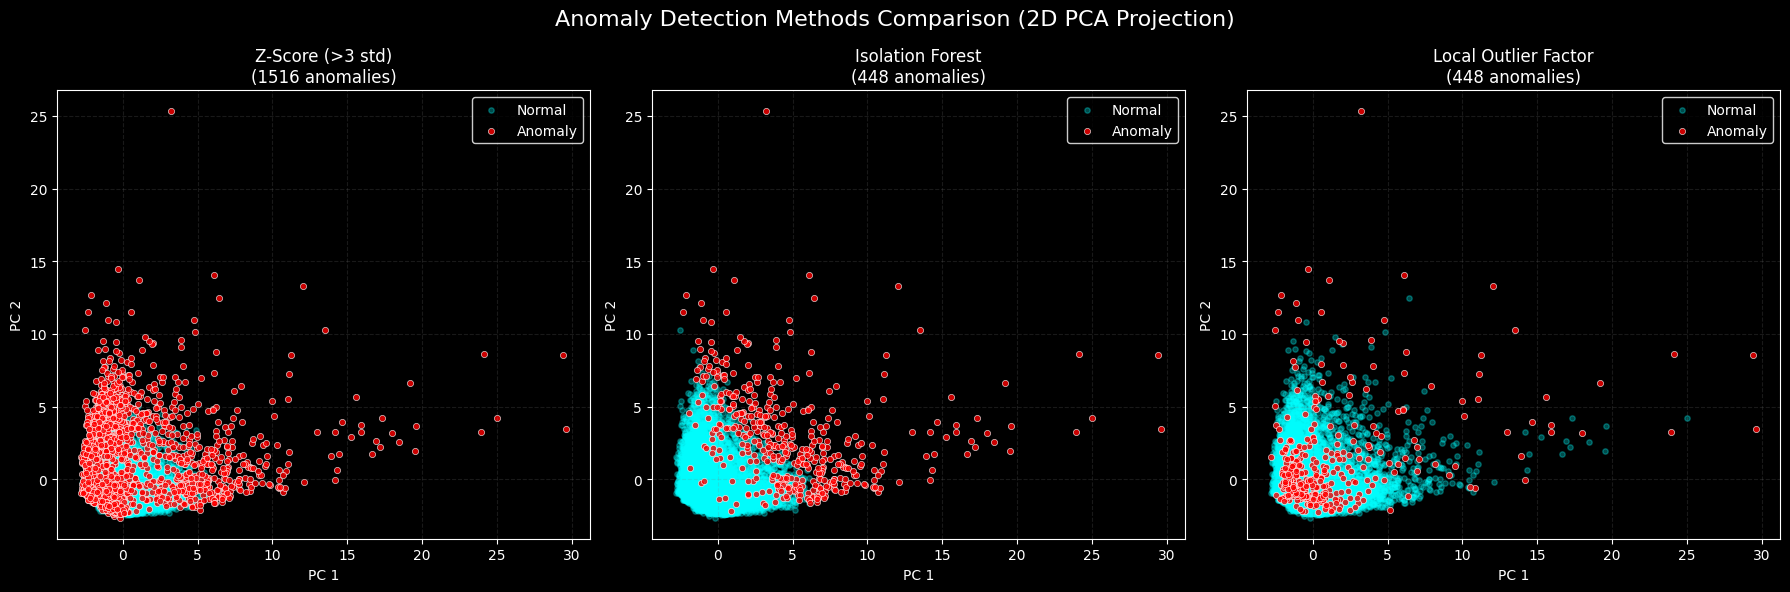

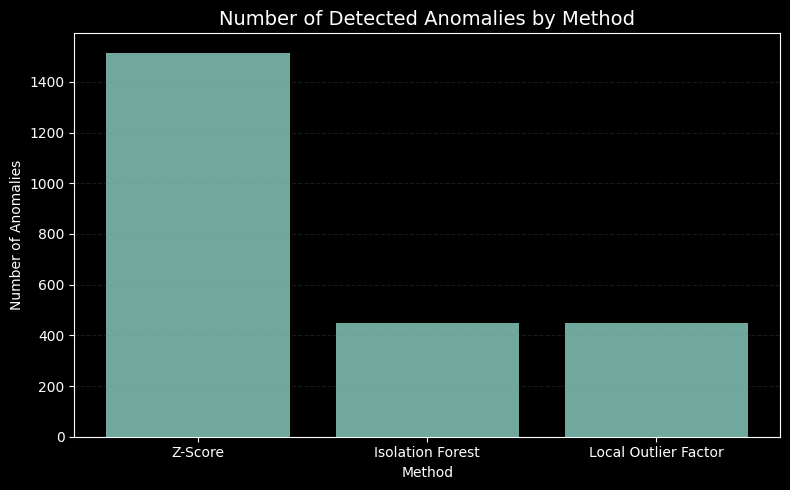

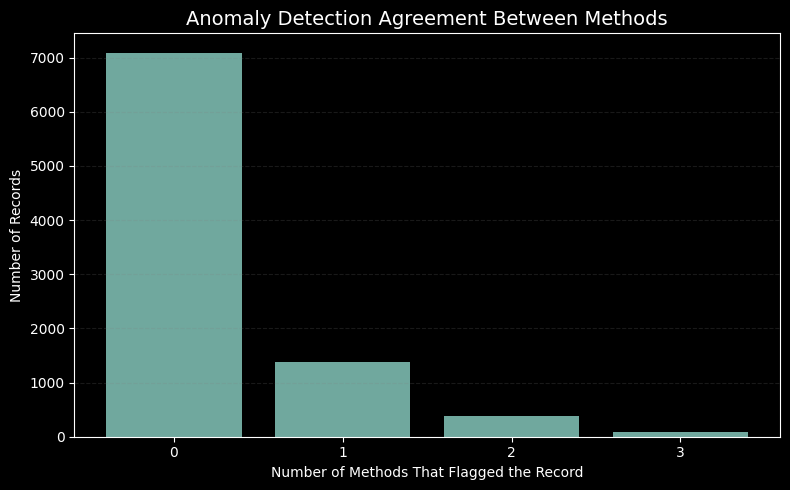

In [87]:
# =============================================
# ========= Q 5: Anomaly Detection ============
# =============================================

plt.style.use('dark_background')

print("=============================================")
print("--- Section 5: Multi-Dimensional Anomaly Detection ---")
print("=============================================")

X_anomaly = df_scaled_fixed.values
n_samples = X_anomaly.shape[0]

# ---------------------------------------------------------
# Helper function for summary
# ---------------------------------------------------------
def anomaly_summary(method_name, anomaly_mask):
    n_anomalies = np.sum(anomaly_mask)
    anomaly_percent = (n_anomalies / n_samples) * 100

    print(f"\n--- {method_name} ---")
    print(f"Detected anomalies: {n_anomalies}")
    print(f"Percentage of data: {anomaly_percent:.2f}%")

    return {
        "Method": method_name,
        "Anomalies": n_anomalies,
        "Percentage": anomaly_percent
    }


# ---------------------------------------------------------
# 5.1: Z-Score Method
# ---------------------------------------------------------
print("\n--- 5.1: Z-Score Method ---")

# Since the data was already scaled, the standardized values can be interpreted as Z-scores
z_scores = np.abs(df_scaled_fixed)

z_threshold = 3

# Feature-wise anomaly count
z_feature_counts = (z_scores > z_threshold).sum(axis=0).sort_values(ascending=False)

print("\nFeature-wise anomalies using Z-Score:")
display(pd.DataFrame({
    "Feature": z_feature_counts.index,
    "Number of Anomalies": z_feature_counts.values
}))

# Global anomaly: a record is anomalous if at least one feature crosses the threshold
z_anomaly_count_per_record = (z_scores > z_threshold).sum(axis=1)
anomalies_z_global = z_anomaly_count_per_record > 0

# Z-score severity
z_max_score = z_scores.max(axis=1)

z_summary = anomaly_summary("Z-Score", anomalies_z_global)


# ---------------------------------------------------------
# 5.2: Isolation Forest
# ---------------------------------------------------------
print("\n--- 5.2: Isolation Forest ---")

contamination_rate = 0.05

iso_forest = IsolationForest(
    contamination=contamination_rate,
    random_state=42
)

if_preds = iso_forest.fit_predict(X_anomaly)
anomalies_if = if_preds == -1

# Lower decision function values are more anomalous
if_scores = -iso_forest.decision_function(X_anomaly)

if_summary = anomaly_summary("Isolation Forest", anomalies_if)


# ---------------------------------------------------------
# 5.3: Local Outlier Factor (LOF)
# ---------------------------------------------------------
print("\n--- 5.3: Local Outlier Factor (LOF) ---")

lof_neighbors = 20

lof = LocalOutlierFactor(
    n_neighbors=lof_neighbors,
    contamination=contamination_rate
)

lof_preds = lof.fit_predict(X_anomaly)
anomalies_lof = lof_preds == -1

# Higher values after multiplying by -1 indicate stronger outlier behavior
lof_scores = -lof.negative_outlier_factor_

lof_summary = anomaly_summary("Local Outlier Factor", anomalies_lof)


# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------
print("\n--- Anomaly Detection Summary Table ---")

anomaly_results = pd.DataFrame([
    z_summary,
    if_summary,
    lof_summary
])

display(anomaly_results)


# ---------------------------------------------------------
# Overlap between methods
# ---------------------------------------------------------
print("\n--- Overlap Between Anomaly Detection Methods ---")

overlap_df = pd.DataFrame({
    "Z-Score": anomalies_z_global,
    "Isolation Forest": anomalies_if,
    "LOF": anomalies_lof
})

overlap_df["Number of Methods"] = overlap_df.sum(axis=1)

overlap_counts = overlap_df["Number of Methods"].value_counts().sort_index()

display(pd.DataFrame({
    "Number of Methods That Flagged the Record": overlap_counts.index,
    "Number of Records": overlap_counts.values
}))

print(f"Flagged by all three methods: {np.sum(overlap_df['Number of Methods'] == 3)}")
print(f"Flagged by exactly two methods: {np.sum(overlap_df['Number of Methods'] == 2)}")
print(f"Flagged by exactly one method: {np.sum(overlap_df['Number of Methods'] == 1)}")
print(f"Not flagged by any method: {np.sum(overlap_df['Number of Methods'] == 0)}")


# ---------------------------------------------------------
# Pairwise overlap
# ---------------------------------------------------------
print("\n--- Pairwise Overlap ---")

pairwise_overlap = pd.DataFrame({
    "Methods": [
        "Z-Score & Isolation Forest",
        "Z-Score & LOF",
        "Isolation Forest & LOF"
    ],
    "Overlap Count": [
        np.sum(anomalies_z_global & anomalies_if),
        np.sum(anomalies_z_global & anomalies_lof),
        np.sum(anomalies_if & anomalies_lof)
    ]
})

display(pairwise_overlap)


# ---------------------------------------------------------
# Top anomalies by each method
# ---------------------------------------------------------
print("\n--- Top Anomalies by Severity ---")

top_n = 10

top_anomalies = pd.DataFrame({
    "Z_Max_Score": z_max_score,
    "Z_Anomaly_Feature_Count": z_anomaly_count_per_record,
    "Isolation_Forest_Score": if_scores,
    "LOF_Score": lof_scores,
    "Z_Anomaly": anomalies_z_global,
    "IF_Anomaly": anomalies_if,
    "LOF_Anomaly": anomalies_lof
})

print("\nTop anomalies according to Z-Score:")
display(top_anomalies.sort_values(by="Z_Max_Score", ascending=False).head(top_n))

print("\nTop anomalies according to Isolation Forest:")
display(top_anomalies.sort_values(by="Isolation_Forest_Score", ascending=False).head(top_n))

print("\nTop anomalies according to LOF:")
display(top_anomalies.sort_values(by="LOF_Score", ascending=False).head(top_n))


# ---------------------------------------------------------
# LOF sensitivity to k
# ---------------------------------------------------------
print("\n--- LOF Sensitivity to n_neighbors (k) ---")

lof_k_values = [5, 10, 20, 35, 50]
lof_sensitivity_results = []

for k in lof_k_values:
    lof_temp = LocalOutlierFactor(
        n_neighbors=k,
        contamination=contamination_rate
    )

    lof_temp_preds = lof_temp.fit_predict(X_anomaly)
    lof_temp_anomalies = lof_temp_preds == -1

    lof_sensitivity_results.append({
        "n_neighbors (k)": k,
        "Detected Anomalies": np.sum(lof_temp_anomalies),
        "Percentage": (np.sum(lof_temp_anomalies) / n_samples) * 100
    })

lof_sensitivity_df = pd.DataFrame(lof_sensitivity_results)
display(lof_sensitivity_df)


# ---------------------------------------------------------
# Visualization: PCA projection comparison
# ---------------------------------------------------------
print("\n--- Generating PCA Visualization ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Anomaly Detection Methods Comparison (2D PCA Projection)', color='white', fontsize=16)

methods = [
    ("Z-Score (>3 std)", anomalies_z_global),
    ("Isolation Forest", anomalies_if),
    ("Local Outlier Factor", anomalies_lof)
]

for ax, (title, is_anomaly) in zip(axes, methods):
    ax.scatter(
        pc1[~is_anomaly],
        pc2[~is_anomaly],
        c='cyan',
        alpha=0.3,
        s=15,
        label='Normal'
    )

    ax.scatter(
        pc1[is_anomaly],
        pc2[is_anomaly],
        c='red',
        alpha=0.8,
        s=20,
        label='Anomaly',
        edgecolors='white',
        linewidth=0.5
    )

    ax.set_title(f"{title}\n({is_anomaly.sum()} anomalies)", color='white')
    ax.set_xlabel('PC 1', color='white')
    ax.set_ylabel('PC 2', color='white')
    ax.tick_params(colors='white')
    ax.grid(color='gray', linestyle='--', alpha=0.2)
    ax.set_facecolor('black')
    ax.legend(facecolor='black', edgecolor='white', labelcolor='white', loc='upper right')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Visualization: number of anomalies by method
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    anomaly_results["Method"],
    anomaly_results["Anomalies"],
    alpha=0.8
)

plt.title("Number of Detected Anomalies by Method", color='white', fontsize=14)
plt.xlabel("Method", color='white')
plt.ylabel("Number of Anomalies", color='white')
plt.tick_params(colors='white')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Visualization: overlap by number of methods
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    overlap_counts.index.astype(str),
    overlap_counts.values,
    alpha=0.8
)

plt.title("Anomaly Detection Agreement Between Methods", color='white', fontsize=14)
plt.xlabel("Number of Methods That Flagged the Record", color='white')
plt.ylabel("Number of Records", color='white')
plt.tick_params(colors='white')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

### 5. Multi-Dimensional Anomaly Detection

## 5.1 Z-Score Method

### Assumption of Gaussianity

**Results:**
- Detected **1,516 anomalies**.
- Represents approximately **16.9% of the dataset**.

**Observations:**
- Z-Score assumes that each feature follows a Gaussian (normal) distribution.
- Financial variables such as balances, purchases, and cash advances are highly skewed and contain long right tails.
- This assumption is therefore unrealistic for many variables in the dataset.

**Evidence from the Feature-Wise Analysis:**
- `TENURE`: 394 anomalies
- `CASH_ADVANCE_FREQUENCY`: 199 anomalies
- `BALANCE`: 196 anomalies
- `PURCHASES_TRX`: 185 anomalies
- `CASH_ADVANCE`: 182 anomalies

At the same time:

- `PURCHASES_FREQUENCY`: 0 anomalies
- `ONEOFF_PURCHASES_FREQUENCY`: 0 anomalies
- `PURCHASES_INSTALLMENTS_FREQUENCY`: 0 anomalies
- `PRC_FULL_PAYMENT`: 0 anomalies

**Conclusion:**
- The large imbalance between variables suggests strong departures from Gaussian behavior and the presence of heavy-tailed distributions.

### Why this Approach May Fail in High Dimensions

**Observations:**
- The dataset contains 17 dimensions.
- A record is flagged if it exceeds the threshold in at least one feature.

**Implications:**
- As dimensionality increases, the probability of exceeding a threshold somewhere also increases.
- This effect causes the number of detected anomalies to grow rapidly.

**Result:**
- Z-Score detected 1,516 anomalies, significantly more than the other methods.

**Conclusion:**
- Feature-wise thresholding can generate many false positives in high-dimensional datasets.

### Feature-Wise vs Global Anomaly Detection

**Feature-Wise Nature:**
- Each feature is evaluated independently.
- The final decision combines independent feature violations.

**Limitation:**
- Relationships between variables are ignored.
- A record may appear normal in every feature individually while still representing an unusual combination of values.

**Evidence:**
- The PCA projection shows that Z-Score labels a large portion of the data cloud as anomalous.

**Conclusion:**
- Z-Score is effective for detecting extreme individual values but cannot capture multidimensional behavioral patterns.


## 5.2 Isolation Forest

**Results:**
- Detected **448 anomalies**.
- Represents approximately **5.0% of the dataset**.

### Isolation Mechanism

**Key Idea:**
- Isolation Forest does not model normal behavior.
- Instead, it attempts to isolate observations.

**Intuition:**
- Rare and unusual observations require fewer splits to become isolated.

### Random Partitioning

The algorithm repeatedly performs:

- Random feature selection.
- Random split-value selection.

**Effect:**
- Anomalies are isolated quickly.
- Normal observations require deeper traversal through the trees.

### Contamination Parameter

**Configuration:**

contamination = 0.05

**Meaning:**
- Approximately 5% of the observations are expected to be anomalous.

**Result:**
- Isolation Forest detected 448 anomalies, matching the contamination assumption.

### Advantages in High-Dimensional Settings

**Strengths:**
- Does not rely on pairwise distance calculations.
- Less affected by the Curse of Dimensionality.
- Remains computationally efficient as dimensionality increases.

### Interpretation of the Results

**Observations from the PCA Projection:**
- Most anomalies appear at the outer boundaries of the data cloud.
- Extreme observations are isolated from the dense customer population.

**Evidence from the Top-Anomaly Table:**
- Many highly ranked Isolation Forest anomalies also have extreme Z-Scores.
- Several are detected by multiple methods simultaneously.

**Conclusion:**
- Isolation Forest primarily identifies globally unusual customer behavior.


## 5.3 Local Outlier Factor (LOF)

**Results:**
- Detected **448 anomalies**.
- Represents approximately **5.0% of the dataset**.

### Local Density Estimation

**Key Idea:**
- LOF evaluates observations relative to their local neighborhood.

**Process:**
- Estimate local density around each observation.
- Compare that density to the density of neighboring observations.

**Decision Rule:**
- Lower local density relative to neighbors indicates a potential anomaly.

### Neighborhood Effects

**Observations:**
- LOF focuses on local structure rather than global position.
- Some anomalies are located close to the dense customer population.

**Evidence:**
- In the PCA projection, LOF identifies anomalies that are not necessarily far from the global center.

### Difference Between Global and Local Anomalies

**Isolation Forest:**
- Detects global anomalies.
- Focuses on observations that are unusual relative to the entire dataset.

**LOF:**
- Detects local anomalies.
- Focuses on observations that appear unusual relative to nearby observations.

**Evidence:**
- Several LOF anomalies were not detected by either Z-Score or Isolation Forest.

### Sensitivity to Parameter k

LOF was evaluated using:

- k = 5
- k = 10
- k = 20
- k = 35
- k = 50

**Result:**
- All tested values produced exactly 448 anomalies.

**Conclusion:**
- The local density structure appears stable.
- LOF results are not highly sensitive to moderate changes in neighborhood size.


## Comparison of the Methods

| Method | Detected Anomalies | Percentage |
|----------|----------|----------|
| Z-Score | 1516 | 16.9% |
| Isolation Forest | 448 | 5.0% |
| LOF | 448 | 5.0% |

### Key Observations

- Z-Score detected substantially more anomalies.
- Isolation Forest and LOF produced much more conservative estimates.
- Multidimensional methods appear less sensitive to skewed feature distributions.


## Agreement Between Methods

### Overall Agreement

| Number of Methods Flagging the Observation | Records |
|----------|----------|
| 0 | 7094 |
| 1 | 1387 |
| 2 | 382 |
| 3 | 87 |

### Interpretation

- Only **87 observations** were detected by all three methods.
- These observations are likely the strongest anomaly candidates.
- Most detected anomalies are method-specific.

### Pairwise Overlap

- Z-Score & Isolation Forest: 392 observations
- Z-Score & LOF: 156 observations
- Isolation Forest & LOF: 95 observations

### Conclusion

- Global and local anomaly detection identify different forms of unusual behavior.
- Different anomaly definitions lead to different anomaly sets.


## Overall Interpretation

### Z-Score

- Detects extreme values in individual features.
- Sensitive to skewed distributions and high dimensionality.

### Isolation Forest

- Detects globally unusual observations.
- Robust to high dimensionality.
- Produces stable and interpretable anomaly sets.

### LOF

- Detects locally sparse observations.
- Captures anomalies that may appear normal globally.
- Provides a complementary perspective to Isolation Forest.

### Final Conclusion

- No single method captures all anomaly types.
- Only 87 observations were consistently detected by all three approaches.
- Combining multiple methods provides a more complete understanding of unusual customer behavior.
- Using both global and local perspectives is essential when analyzing high-dimensional financial datasets.

--- Section 6: Comparison Section ---

--- Shared and Method-Specific Anomalies ---


,Category,Number of Records
0,All Three Methods,87
1,Z-Score & Isolation Forest Only,305
2,Z-Score & LOF Only,69
3,Isolation Forest & LOF Only,8
4,Z-Score Only,1055
5,Isolation Forest Only,48
6,LOF Only,284
7,Not Flagged by Any Method,7094



--- Agreement Count Between Methods ---


,Number of Methods That Flagged the Record,Number of Records
0,0,7094
1,1,1387
2,2,382
3,3,87



--- Runtime Comparison ---


...

,Method,Original 17D Anomalies,PCA 7D Anomalies,Overlap Between 17D and PCA 7D
0,Z-Score,1516,541,532
1,Isolation Forest,448,448,277
2,LOF,448,448,244



--- Method Properties Comparison ---


,Method,Sensitivity to Scaling,Sensitivity to Dimensionality,Robustness to Noise,Interpretability,Main Risk
0,Z-Score,High,High,Low,High,High false positives in skewed/high-dimensiona...
1,Isolation Forest,Medium,Medium,High,Medium,May miss subtle local anomalies
2,LOF,High,High,Medium,Medium-Low,Sensitive to neighborhood size and local density



--- False Positives vs False Negatives Support Table ---


,Method,Detected Anomalies,Likely False Positive Risk,Likely False Negative Risk,Reason
0,Z-Score,1516,High,"Lower for feature-wise extreme values, higher ...",Flags any record extreme in at least one feature
1,Isolation Forest,448,Medium,Medium; may miss local anomalies,Focuses on global isolation
2,LOF,448,Medium,Medium; may miss global anomalies,Focuses on local density


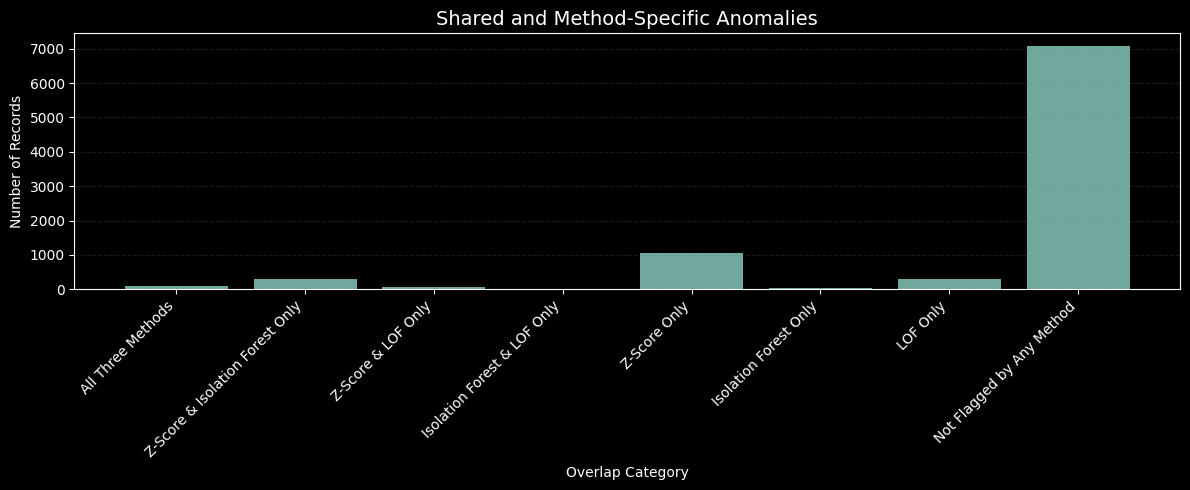

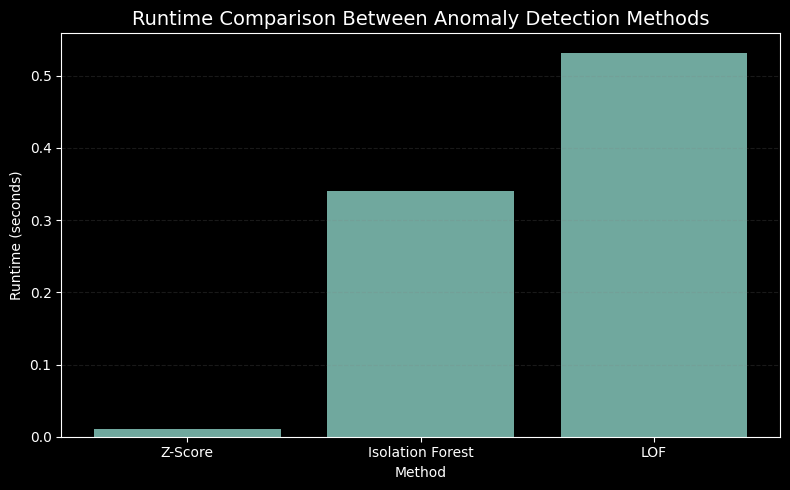

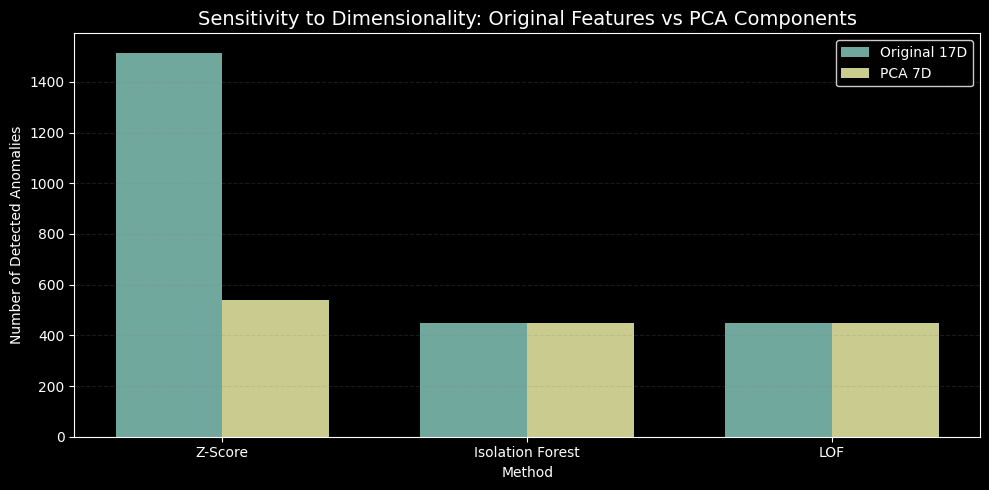

In [88]:
# =============================================
# ============ Q 6: Comparison Section =========
# =============================================

plt.style.use('dark_background')

print("=============================================")
print("--- Section 6: Comparison Section ---")
print("=============================================")

# ---------------------------------------------------------
# Create comparison DataFrame from anomaly masks
# ---------------------------------------------------------

overlap_df = pd.DataFrame({
    "Z-Score": anomalies_z_global,
    "Isolation Forest": anomalies_if,
    "LOF": anomalies_lof
})

overlap_df["Number of Methods"] = overlap_df.sum(axis=1)

# ---------------------------------------------------------
# Shared and method-specific anomalies
# ---------------------------------------------------------

print("\n--- Shared and Method-Specific Anomalies ---")

all_three = np.sum(
    overlap_df["Z-Score"] &
    overlap_df["Isolation Forest"] &
    overlap_df["LOF"]
)

z_if_only = np.sum(
    overlap_df["Z-Score"] &
    overlap_df["Isolation Forest"] &
    ~overlap_df["LOF"]
)

z_lof_only = np.sum(
    overlap_df["Z-Score"] &
    ~overlap_df["Isolation Forest"] &
    overlap_df["LOF"]
)

if_lof_only = np.sum(
    ~overlap_df["Z-Score"] &
    overlap_df["Isolation Forest"] &
    overlap_df["LOF"]
)

z_only = np.sum(
    overlap_df["Z-Score"] &
    ~overlap_df["Isolation Forest"] &
    ~overlap_df["LOF"]
)

if_only = np.sum(
    ~overlap_df["Z-Score"] &
    overlap_df["Isolation Forest"] &
    ~overlap_df["LOF"]
)

lof_only = np.sum(
    ~overlap_df["Z-Score"] &
    ~overlap_df["Isolation Forest"] &
    overlap_df["LOF"]
)

none_flagged = np.sum(overlap_df["Number of Methods"] == 0)

overlap_summary = pd.DataFrame({
    "Category": [
        "All Three Methods",
        "Z-Score & Isolation Forest Only",
        "Z-Score & LOF Only",
        "Isolation Forest & LOF Only",
        "Z-Score Only",
        "Isolation Forest Only",
        "LOF Only",
        "Not Flagged by Any Method"
    ],
    "Number of Records": [
        all_three,
        z_if_only,
        z_lof_only,
        if_lof_only,
        z_only,
        if_only,
        lof_only,
        none_flagged
    ]
})

display(overlap_summary)

# ---------------------------------------------------------
# Agreement count table
# ---------------------------------------------------------

print("\n--- Agreement Count Between Methods ---")

agreement_counts = overlap_df["Number of Methods"].value_counts().sort_index()

agreement_summary = pd.DataFrame({
    "Number of Methods That Flagged the Record": agreement_counts.index,
    "Number of Records": agreement_counts.values
})

display(agreement_summary)

# ---------------------------------------------------------
# Runtime comparison
# ---------------------------------------------------------

print("\n--- Runtime Comparison ---")

runtime_results = []

X_comparison = df_scaled_fixed.values

# Z-Score runtime
start_time = time.time()
z_scores_runtime = np.abs(df_scaled_fixed)
z_runtime_mask = (z_scores_runtime > 3).sum(axis=1) > 0
z_runtime = time.time() - start_time

runtime_results.append({
    "Method": "Z-Score",
    "Runtime (seconds)": z_runtime,
    "Detected Anomalies": np.sum(z_runtime_mask)
})

# Isolation Forest runtime
start_time = time.time()
iso_runtime_model = IsolationForest(
    contamination=0.05,
    random_state=42
)
iso_runtime_preds = iso_runtime_model.fit_predict(X_comparison)
iso_runtime_mask = iso_runtime_preds == -1
iso_runtime = time.time() - start_time

runtime_results.append({
    "Method": "Isolation Forest",
    "Runtime (seconds)": iso_runtime,
    "Detected Anomalies": np.sum(iso_runtime_mask)
})

# LOF runtime
start_time = time.time()
lof_runtime_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)
lof_runtime_preds = lof_runtime_model.fit_predict(X_comparison)
lof_runtime_mask = lof_runtime_preds == -1
lof_runtime = time.time() - start_time

runtime_results.append({
    "Method": "LOF",
    "Runtime (seconds)": lof_runtime,
    "Detected Anomalies": np.sum(lof_runtime_mask)
})

runtime_df = pd.DataFrame(runtime_results)
display(runtime_df)

# ---------------------------------------------------------
# Sensitivity to dimensionality: original 17D vs PCA 7D
# ---------------------------------------------------------

print("\n--- Sensitivity to Dimensionality: Original Features vs PCA Components ---")

# Use the first 7 PCA components because Section 3 showed they explain about 80% of the variance
X_pca_7 = X_pca[:, :7]

dimensionality_results = []

# Z-Score on PCA 7D
z_pca_scores = np.abs(stats.zscore(X_pca_7))
z_pca_mask = (z_pca_scores > 3).sum(axis=1) > 0

dimensionality_results.append({
    "Method": "Z-Score",
    "Original 17D Anomalies": np.sum(anomalies_z_global),
    "PCA 7D Anomalies": np.sum(z_pca_mask),
    "Overlap Between 17D and PCA 7D": np.sum(anomalies_z_global & z_pca_mask)
})

# Isolation Forest on PCA 7D
iso_pca_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_pca_preds = iso_pca_model.fit_predict(X_pca_7)
iso_pca_mask = iso_pca_preds == -1

dimensionality_results.append({
    "Method": "Isolation Forest",
    "Original 17D Anomalies": np.sum(anomalies_if),
    "PCA 7D Anomalies": np.sum(iso_pca_mask),
    "Overlap Between 17D and PCA 7D": np.sum(anomalies_if & iso_pca_mask)
})

# LOF on PCA 7D
lof_pca_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_pca_preds = lof_pca_model.fit_predict(X_pca_7)
lof_pca_mask = lof_pca_preds == -1

dimensionality_results.append({
    "Method": "LOF",
    "Original 17D Anomalies": np.sum(anomalies_lof),
    "PCA 7D Anomalies": np.sum(lof_pca_mask),
    "Overlap Between 17D and PCA 7D": np.sum(anomalies_lof & lof_pca_mask)
})

dimensionality_df = pd.DataFrame(dimensionality_results)
display(dimensionality_df)

# ---------------------------------------------------------
# Scaling and interpretability comparison table
# ---------------------------------------------------------

print("\n--- Method Properties Comparison ---")

method_properties = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    "Sensitivity to Scaling": [
        "High",
        "Medium",
        "High"
    ],
    "Sensitivity to Dimensionality": [
        "High",
        "Medium",
        "High"
    ],
    "Robustness to Noise": [
        "Low",
        "High",
        "Medium"
    ],
    "Interpretability": [
        "High",
        "Medium",
        "Medium-Low"
    ],
    "Main Risk": [
        "High false positives in skewed/high-dimensional data",
        "May miss subtle local anomalies",
        "Sensitive to neighborhood size and local density"
    ]
})

display(method_properties)

# ---------------------------------------------------------
# False positives vs false negatives discussion support
# ---------------------------------------------------------

print("\n--- False Positives vs False Negatives Support Table ---")

fp_fn_table = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "LOF"
    ],
    "Detected Anomalies": [
        np.sum(anomalies_z_global),
        np.sum(anomalies_if),
        np.sum(anomalies_lof)
    ],
    "Likely False Positive Risk": [
        "High",
        "Medium",
        "Medium"
    ],
    "Likely False Negative Risk": [
        "Lower for feature-wise extreme values, higher for multivariate anomalies",
        "Medium; may miss local anomalies",
        "Medium; may miss global anomalies"
    ],
    "Reason": [
        "Flags any record extreme in at least one feature",
        "Focuses on global isolation",
        "Focuses on local density"
    ]
})

display(fp_fn_table)

# ---------------------------------------------------------
# Visualization: overlap categories
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.bar(
    overlap_summary["Category"],
    overlap_summary["Number of Records"],
    alpha=0.8
)

plt.title("Shared and Method-Specific Anomalies", color='white', fontsize=14)
plt.xlabel("Overlap Category", color='white')
plt.ylabel("Number of Records", color='white')
plt.xticks(rotation=45, ha='right')
plt.tick_params(colors='white')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization: runtime comparison
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    runtime_df["Method"],
    runtime_df["Runtime (seconds)"],
    alpha=0.8
)

plt.title("Runtime Comparison Between Anomaly Detection Methods", color='white', fontsize=14)
plt.xlabel("Method", color='white')
plt.ylabel("Runtime (seconds)", color='white')
plt.tick_params(colors='white')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization: dimensionality sensitivity
# ---------------------------------------------------------

x = np.arange(len(dimensionality_df["Method"]))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    dimensionality_df["Original 17D Anomalies"],
    width,
    label="Original 17D",
    alpha=0.8
)

plt.bar(
    x + width / 2,
    dimensionality_df["PCA 7D Anomalies"],
    width,
    label="PCA 7D",
    alpha=0.8
)

plt.title("Sensitivity to Dimensionality: Original Features vs PCA Components", color='white', fontsize=14)
plt.xlabel("Method", color='white')
plt.ylabel("Number of Detected Anomalies", color='white')
plt.xticks(x, dimensionality_df["Method"])
plt.tick_params(colors='white')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.2)
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()

### 6. Comparison Section

**Shared Anomalies Between Methods**

* Only **87 observations** were detected by all three methods simultaneously.
* These observations represent the strongest anomaly candidates in the dataset because three fundamentally different algorithms reached the same conclusion.
* In contrast, **7,094 observations** were not flagged by any method, indicating strong agreement regarding the majority of customers.
* The overlap analysis therefore suggests that truly obvious anomalies are relatively rare.

**Method-Specific Anomalies**

* **Z-Score uniquely detected 1,055 observations**, far more than any other method.
* This indicates that Z-Score is much more aggressive and heavily influenced by extreme values in individual features.
* **LOF uniquely detected 284 observations**, suggesting the existence of local-density anomalies that are not necessarily globally unusual.
* **Isolation Forest uniquely detected only 48 observations**, indicating greater consistency with the other methods.

**Sensitivity to Scaling**

* All methods were applied after standardization using `StandardScaler`.
* Z-Score is highly dependent on scaling because it measures deviations in standard deviation units.
* LOF is also highly sensitive because neighborhood distances directly determine local density estimates.
* Isolation Forest is less sensitive since it relies on recursive feature partitioning rather than distance calculations.

**Sensitivity to Dimensionality**

* The dimensionality analysis compared the original **17-dimensional dataset** against the first **7 PCA components**, which explain approximately 80% of the variance.
* Z-Score showed the highest sensitivity, decreasing from **1,516 anomalies** to **541 anomalies** after PCA reduction.
* Isolation Forest detected **448 anomalies** in both cases, while LOF also detected **448 anomalies**.
* However, the overlap analysis revealed that many of the specific observations changed after dimensionality reduction.
* These results indicate that Z-Score is strongly affected by dimensionality, whereas Isolation Forest and LOF are more stable regarding the number of detected anomalies.

**Runtime Considerations**

* The exact runtime values changed slightly between executions, so I did not treat the specific numbers as fixed results.
* In all runs, Z-Score was the fastest method because it only requires direct feature-wise calculations.
* Isolation Forest required more time because it builds an ensemble of random trees.
* LOF was generally the slowest method because it depends on neighborhood-distance calculations.
* For this dataset, the runtime differences were still relatively small, but the gap may become more important for larger datasets.

**Robustness to Noise**

* Z-Score appears the least robust to noise, detecting **1,516 anomalies**, more than three times the number detected by the other methods.
* Extreme observations directly affect the statistical thresholds used by Z-Score.
* Isolation Forest demonstrated strong robustness by maintaining a relatively conservative anomaly count.
* LOF showed moderate robustness because local density estimates can be affected by naturally varying neighborhood structures.

**Interpretability**

* Z-Score is the most interpretable method because every anomaly can be explained by its deviation from the mean.
* Isolation Forest provides moderate interpretability through tree-based isolation paths.
* LOF is the most difficult method to interpret because its decisions are based on local density ratios.
* From a business perspective, Z-Score explanations are generally the easiest to communicate.

**False Positives vs. False Negatives**

* Since no ground-truth anomaly labels exist, true false-positive and false-negative rates cannot be calculated directly.
* The large number of unique detections produced by Z-Score suggests a relatively high risk of false positives.
* Isolation Forest appears to provide the best balance between false positives and false negatives.
* LOF may identify anomalies missed by global methods, but it can also generate additional detections due to local density variations.
* Overall, Isolation Forest appears to offer the strongest trade-off between detection quality, robustness, and scalability.

**Overall Comparison**

* Z-Score is the fastest and most interpretable method but is highly sensitive to dimensionality and extreme values.
* Isolation Forest provides the best overall balance between robustness, scalability, and anomaly quality.
* LOF contributes unique local anomaly detection capabilities that cannot be captured by global methods.
* The relatively small agreement between methods demonstrates that anomaly detection strongly depends on the underlying mathematical definition of an anomaly.

### 7. Critical Analysis and Reflection

**Fundamental Challenges in Anomaly Detection**

* **Why anomaly detection is fundamentally difficult:** Anomaly detection lacks a universal definition of "normalcy". Because anomalies are, by definition, rare and often evolve over time (concept drift), models are essentially trained on incomplete information. Distinguishing between a legitimate extreme behavior and an actual system error or fraudulent activity is often subjective and context-dependent.
* **Curse of Dimensionality & Problematic Distance:** In high-dimensional spaces, the volume of the space increases exponentially, causing data points to become increasingly sparse. Consequently, the concept of "distance" (like Euclidean distance used in K-Means or LOF) becomes mathematically unstable. Points that appear far apart in 17 dimensions may seem close in a projected 2D space, leading to significant interpretation errors.
* **Noise vs. Anomaly:** A critical distinction must be made between *noise* (random measurement error or artifacts) and *anomalies* (meaningful, albeit rare, events). Noise is typically uniformly distributed and lacks structural significance, whereas anomalies often represent genuine, actionable deviations in behavior that require investigation.
* **Danger of Gaussian Assumptions:** Many traditional methods (like Z-Score) assume Gaussianity. This is highly dangerous in real-world data, which is frequently heavy-tailed. Assuming a bell-curve distribution on skewed financial data leads to high rates of False Positives, as demonstrated by the Z-Score method in this project, which detected substantially more anomalies than the other approaches.
* **Misleading Visualizations:** Post-dimensionality reduction (like PCA), visualizations can be highly deceptive. Since PCA only retains global variance, it can merge distinct local sub-clusters or create artificial patterns, leading analysts to make incorrect conclusions about data structure that do not exist in the higher-dimensional reality.

**Ethical Considerations**

* **False Alarms:** In high-stakes environments, false alarms are not merely technical inconveniences; they erode trust in the system. If a cybersecurity tool flags too many false positives, security teams may develop "alert fatigue" and ignore legitimate threats.
* **Surveillance:** The automation of anomaly detection carries the risk of excessive surveillance, where benign deviations in personal behavior are pathologized or penalized without transparency or due process.
* **Medical Applications:** In medicine, anomaly detection can be life-saving for identifying early disease markers, but a False Negative (missing an anomaly) could mean a missed diagnosis, while a False Positive could lead to unnecessary and invasive medical procedures, causing physical and psychological harm.
* **Cybersecurity Applications:** While anomaly detection is vital for identifying novel cyberattacks, the ethical challenge lies in the "black box" nature of these models. When a system blocks an account or a transaction, it must be interpretable; opaque automated decisions raise significant concerns regarding fairness, accountability, and the potential for systemic bias against specific user groups.

--- Generating Final Dashboard Visualizations ---

1. Generating Correlation Heatmap...


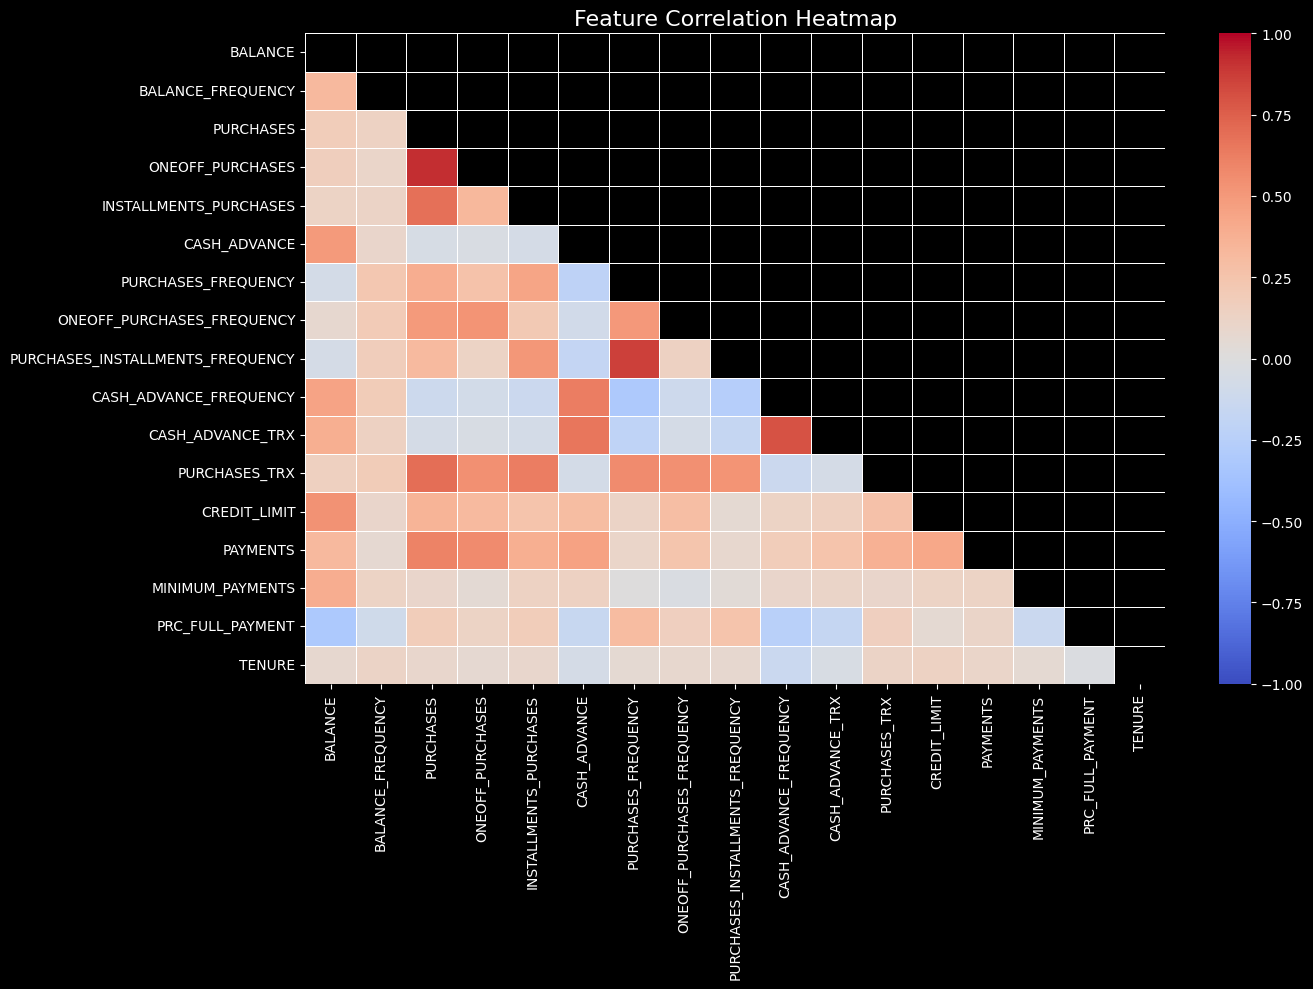


2. Generating 2D PCA Cluster & Anomaly View...


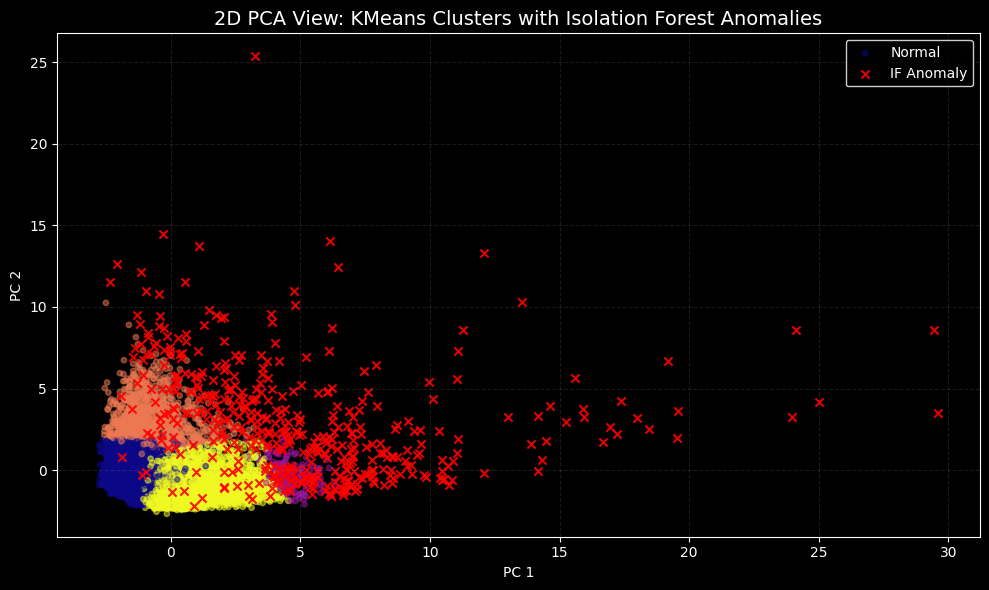


3. Generating Pairplot (Top 4 Principal Components)...


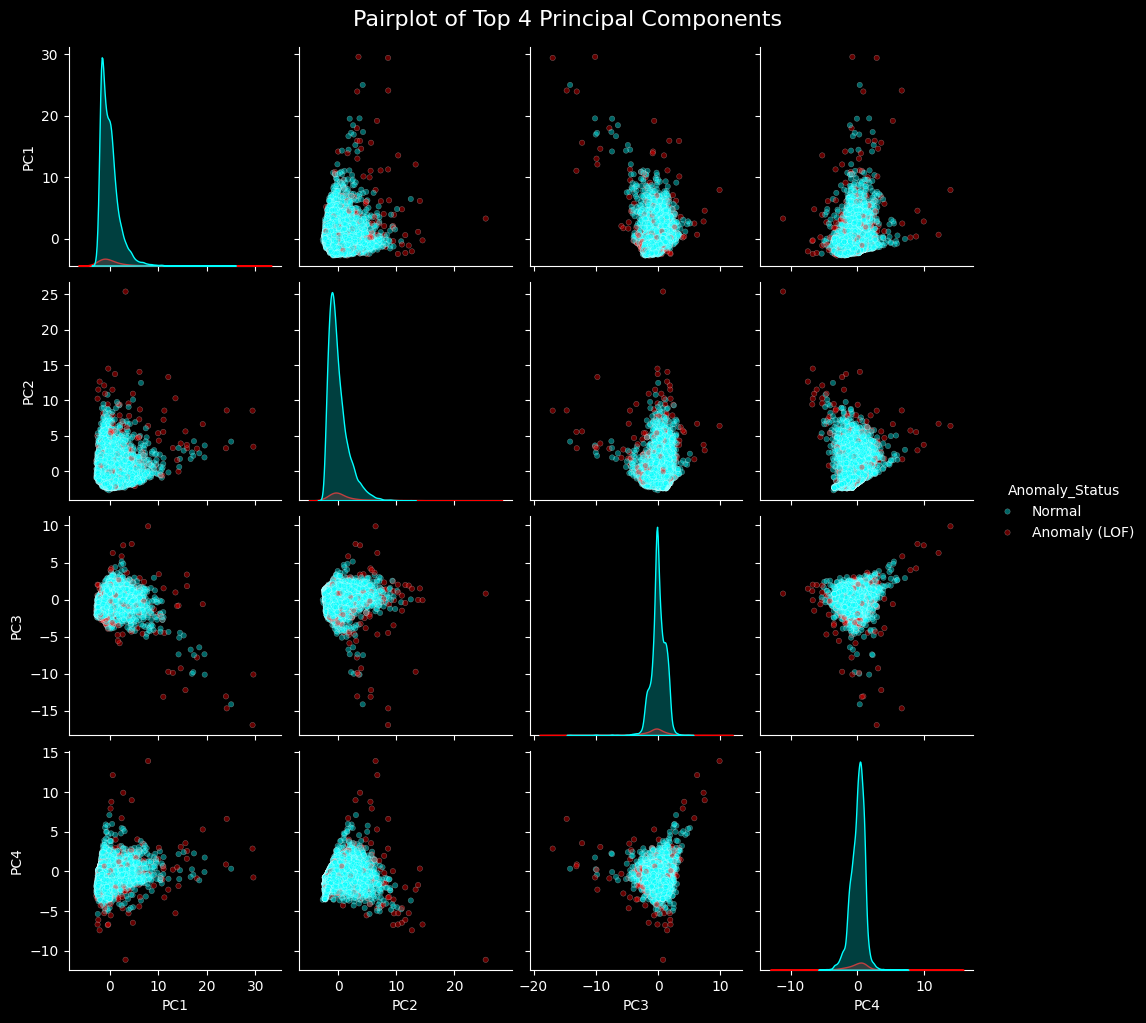


4. Generating Interactive 3D Dashboard...


In [89]:
# =============================================
# ====== Q 8: Final Visualization Dashboard ===
# =============================================

print("--- Generating Final Dashboard Visualizations ---")

plt.style.use('dark_background')

# ---------------------------------------------------------
# 1. Feature Correlation Heatmap
# ---------------------------------------------------------
print("\n1. Generating Correlation Heatmap...")

plt.figure(figsize=(14, 10))

corr_matrix = df_scaled_fixed.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Feature Correlation Heatmap', color='white', fontsize=16)
plt.tick_params(colors='white')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. 2D PCA Cluster and Anomaly View
# ---------------------------------------------------------
print("\n2. Generating 2D PCA Cluster & Anomaly View...")

plt.figure(figsize=(10, 6))

plt.scatter(
    pc1[~anomalies_if],
    pc2[~anomalies_if],
    c=kmeans_labels[~anomalies_if],
    cmap='plasma',
    alpha=0.5,
    s=15,
    label='Normal'
)

plt.scatter(
    pc1[anomalies_if],
    pc2[anomalies_if],
    c='red',
    alpha=0.9,
    s=35,
    marker='x',
    label='IF Anomaly'
)

plt.title('2D PCA View: KMeans Clusters with Isolation Forest Anomalies', color='white', fontsize=14)
plt.xlabel('PC 1', color='white')
plt.ylabel('PC 2', color='white')
plt.tick_params(colors='white')
plt.grid(color='gray', linestyle='--', alpha=0.2)
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Pairplot of Top Principal Components
# ---------------------------------------------------------
print("\n3. Generating Pairplot (Top 4 Principal Components)...")

df_pca_pair = pd.DataFrame({
    'PC1': pc1,
    'PC2': pc2,
    'PC3': pc3,
    'PC4': X_pca[:, 3],
    'Anomaly_Status': ['Anomaly (LOF)' if x else 'Normal' for x in anomalies_lof]
})

pair_plot = sns.pairplot(
    df_pca_pair,
    hue='Anomaly_Status',
    palette={
        'Normal': 'cyan',
        'Anomaly (LOF)': 'red'
    },
    plot_kws={
        'alpha': 0.4,
        's': 15
    }
)

pair_plot.fig.suptitle(
    'Pairplot of Top 4 Principal Components',
    color='white',
    y=1.02,
    fontsize=16
)

for ax in pair_plot.axes.flatten():
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.set_facecolor('black')

plt.show()


# ---------------------------------------------------------
# 4. Interactive 3D Anomaly and Cluster Exploration
# ---------------------------------------------------------
print("\n4. Generating Interactive 3D Dashboard...")

df_interactive = pd.DataFrame({
    'PC1': pc1,
    'PC2': pc2,
    'PC3': pc3,
    'KMeans_Cluster': kmeans_labels.astype(str),
    'Is_Anomaly_IF': anomalies_if
})

df_interactive['Status'] = df_interactive['Is_Anomaly_IF'].apply(
    lambda x: 'Anomaly' if x else 'Normal'
)

fig = px.scatter_3d(
    df_interactive,
    x='PC1',
    y='PC2',
    z='PC3',
    color='KMeans_Cluster',
    symbol='Status',
    symbol_sequence=['circle', 'x'],
    color_discrete_sequence=px.colors.qualitative.Set1,
    title='Interactive Exploration: KMeans Clusters (Colors) & IF Anomalies (Symbols)',
    opacity=0.7,
    labels={
        'KMeans_Cluster': 'Cluster ID',
        'Status': 'Status'
    }
)

fig.update_layout(
    template='plotly_dark',
    scene=dict(
        xaxis=dict(title='PC 1', backgroundcolor="black", gridcolor="#333333"),
        yaxis=dict(title='PC 2', backgroundcolor="black", gridcolor="#333333"),
        zaxis=dict(title='PC 3', backgroundcolor="black", gridcolor="#333333")
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


### 8. Final Visualization Dashboard

The final dashboard summarizes the main findings from the PCA, clustering, feature-correlation, and anomaly detection stages. It provides both static and interactive views of the dataset, allowing the results to be interpreted visually from several perspectives.

**1. Feature Correlation Heatmap**

* The heatmap visualizes the linear relationships between the standardized features.
* Strong correlation patterns are visible among related feature families, especially within the `PURCHASES` variables and the `CASH_ADVANCE` variables.
* These correlation blocks support the earlier feature-space clustering results, where related behavioral metrics were grouped together.
* The heatmap also confirms the presence of redundancy and collinearity, which justifies the use of PCA for dimensionality reduction.

**2. 2D PCA View: K-Means Clusters with Isolation Forest Anomalies**

* This visualization combines dimensionality reduction, clustering, and anomaly detection in a single 2D view.
* The colors represent the K-Means cluster assignments, showing how the algorithm partitions the customer population into four regions.
* The red “X” markers represent anomalies detected by Isolation Forest.
* Most anomalies appear around the outer boundaries and long tails of the data cloud, which is consistent with Isolation Forest identifying globally unusual observations.
* This plot also shows that some anomalies are located near cluster boundaries, suggesting that unusual observations are not always completely separated from normal customer behavior.

**3. Pairplot of Top Principal Components**

* The pairplot compares the relationships between the first four principal components: PC1, PC2, PC3, and PC4.
* Normal observations are shown in cyan, while LOF anomalies are shown in red.
* The plot reveals that many anomalies appear in the tails of the principal component distributions.
* More importantly, some LOF anomalies are not obvious in the basic PC1–PC2 projection but become more visible when PC3 and PC4 are included.
* This supports the conclusion that relying only on a 2D PCA plot can be misleading because important anomaly patterns may exist in additional dimensions.

**4. Interactive 3D Exploration: Clusters and Anomalies**

* The interactive 3D plot uses PC1, PC2, and PC3 as spatial axes.
* K-Means clusters are represented by different colors.
* Isolation Forest anomalies are represented by different marker symbols, allowing anomalies to be visually separated from normal observations.
* The interactive format allows rotation, zooming, and hovering over individual points, making it easier to explore dense regions and isolated observations.
* This visualization is useful as a summary because it combines segmentation and anomaly detection in one plot.

**Overall Dashboard Interpretation**

* The heatmap confirms strong relationships between groups of related features.
* The PCA-based visualizations show that the dataset contains a dense central population with long-tailed behavior.
* The clustering visualizations show that K-Means divides the continuous customer space into geometric regions.
* The anomaly visualizations show that Isolation Forest and LOF identify different types of unusual observations.
* Overall, the dashboard reinforces the main conclusion of the project: customer behavior in this dataset is not cleanly separated into simple groups, and anomaly detection requires multiple complementary methods rather than relying on a single algorithm or a single visualization.